# Inżynieria pozyskiwania i ochrony wiedzy z danych i baz danych  
## Obfuskator i detektor obfuskacji kodu źródłowego programów  
### Raport 1  

**Autorzy:**  
**Rafał Starypan, Eryk Mika, Kamil Wojcieszak**

---

# 1. Wprowadzenie

Obfuskacja kodu źródłowego (*code obfuscation*) to proces transformacji programu do postaci funkcjonalnie równoważnej, lecz znacząco trudniejszej do zrozumienia i analizy przez człowieka lub narzędzia automatyczne. Technika ta jest powszechnie stosowana w celu ochrony własności intelektualnej, zabezpieczenia algorytmów przed inżynierią wsteczną (*reverse engineering*), a także w kontekście ochrony licencji oprogramowania.

Jednocześnie te same metody obfuskacji wykorzystywane są przez twórców złośliwego oprogramowania w celu ukrycia szkodliwego kodu przed skanerami antywirusowymi i systemami detekcji. Z tego powodu rozwój technik zarówno obfuskacji, jak i jej wykrywania, stanowi istotny obszar badawczy w dziedzinie bezpieczeństwa informatycznego.

Niniejszy raport stanowi przegląd literatury naukowej oraz istniejących rozwiązań w zakresie obfuskacji i detekcji obfuskacji kodu źródłowego. Dokument został przygotowany w ramach punktu kontrolnego nr 2 projektu semestralnego.

---

# 2. Klasyfikacja technik obfuskacji

Techniki obfuskacji kodu można podzielić na kilka głównych kategorii, w zależności od poziomu, na którym dokonywana jest transformacja. Poniższa taksonomia opiera się na pracach Collberga i in. (1997) oraz nowszych przeglądach systematycznych, takich jak Xu i in. (2020).

---

## 2.1. Obfuskacja układu (Layout Obfuscation)

Obfuskacja na poziomie układu kodu polega na modyfikacji elementów, które nie wpływają na semantykę programu, ale znacząco utrudniają jego czytelność.

Techniki:

- **Zmiana nazw identyfikatorów (identifier renaming)** – zamiana nazw zmiennych, funkcji i klas na bezsensowne ciągi znaków.  
- **Usuwanie symboli debugowania (stripping)** – usuwanie informacji diagnostycznych, komentarzy i metadanych.  
- **Wstawianie kodu śmieciowego (junk code insertion)** – dodawanie instrukcji bez wpływu na działanie programu.  
- **Separacja kodu logicznie powiązanego** – rozmieszczanie fragmentów realizujących wspólne zadanie w różnych częściach pliku.

---

## 2.2. Obfuskacja przepływu sterowania (Control Flow Obfuscation)

Techniki tej grupy zmieniają strukturę grafu przepływu sterowania programu.

- **Spłaszczanie przepływu sterowania (Control Flow Flattening)** – zastąpienie struktury pętli i warunków jedną instrukcją `switch` sterowaną zmienną stanu.
- **Predykaty nieprzezroczyste (opaque predicates)** – warunki o znanym wyniku, trudne do analizy statycznej.
- **Fałszywy przepływ sterowania (bogus control flow)** – wstawianie bloków kodu, które nigdy nie zostaną wykonane.

---

## 2.3. Obfuskacja danych (Data Obfuscation)

Transformacje struktur danych wykorzystywanych przez program.

- **Szyfrowanie łańcuchów znaków (string encryption)** – przechowywanie stałych tekstowych w postaci zaszyfrowanej.
- **Transformacja tablic** – dzielenie, scalanie, zmiana wymiarowości oraz zmiana kolejności elementów.
- **Mixed Boolean-Arithmetic (MBA)** – zastępowanie prostych wyrażeń arytmetycznych bardziej złożonymi wyrażeniami logiczno-arytmetycznymi.

---

## 2.4. Zaawansowane techniki

- **Wirtualizacja kodu (code virtualization)** – zamiana fragmentu programu w interpreter własnego bytecode.
- **Samomodyfikujący się kod (self-modifying code)** – kod zmieniający własne instrukcje w czasie wykonywania.
- **Pakowanie (packing)** – kompresja programu, który rozpakowuje się dopiero podczas uruchomienia.

---

# 3. Metody detekcji obfuskacji

Detekcja obfuskacji jest kluczowym elementem analizy bezpieczeństwa oprogramowania.

---

## 3.1. Analiza statyczna

Badanie kodu bez jego uruchamiania.

Przykładowe cechy wskazujące na obfuskację:

- wysoka entropia kodu i stringów
- nietypowe nazwy identyfikatorów
- wysoka złożoność cyklomatyczna
- obecność martwego kodu
- nietypowa struktura grafu przepływu sterowania

---

## 3.2. Analiza dynamiczna

Obserwacja programu podczas jego wykonywania.

Pozwala wykryć m.in.:

- rozpakowywanie kodu w pamięci
- deszyfrowanie stringów w runtime
- samomodyfikację kodu
- wirtualizację

Przykładowe narzędzia:

- **KLEE**
- **Pin**
- **DynamoRIO**

---

## 3.3. Podejścia oparte na uczeniu maszynowym

Nowoczesne badania wykorzystują ML do detekcji obfuskacji.

| Praca / Narzędzie | Metoda ML | Cel detekcji | Wyniki |
|---|---|---|---|
| Conti i in. (2022) | CNN / NLP | Obfuskacja aplikacji Android | F-measure 0.985 |
| Adobe SI (Tang 2021) | CNN na poziomie znaków | Obfuskowane komendy systemowe | F1 0.989 |
| Raitsis i in. (2025) | Random Forest, GB, SVM | Pliki EXE i BAT | Accuracy 97.3% |
| ALMOND (2025) | Model językowy | Obfuskacja binarna | Acc 0.948 |
| Wermke i in. (2016) | ML na bytecode | Java malware | Accuracy 99% |
| LLVM IR (2025) | ExtraTrees / CatBoost | Techniki Tigress | Acc 0.948 |

Cechy wykorzystywane przez modele:

- entropia kodu
- statystyki tokenów
- gęstość komentarzy
- liczba słów kluczowych
- reprezentacje wektorowe (np. **IR2Vec**)

---

# 4. Przegląd istniejących narzędzi

## 4.1. Narzędzia obfuskacji

| Narzędzie | Język | Techniki | Typ | Licencja |
|---|---|---|---|---|
| Tigress | C | Virtualization, CFF, MBA | Source-to-source | Darmowy |
| Obfuscator-LLVM | C/C++ | CFF, substitution | LLVM compiler | Open-source |
| ProGuard | Java/Android | Renaming, shrinking | Bytecode | Open-source |
| PyArmor | Python | Bytecode encryption | Bytecode | Komercyjny |
| javascript-obfuscator | JavaScript | CFF, string encryption | Source-to-source | Open-source |
| UPX | Binaria | Packing | Packer | Open-source |

---

## 4.2. Narzędzia detekcji i deobfuskacji

| Narzędzie | Opis | Zastosowanie |
|---|---|---|
| Adobe SI | CNN do wykrywania obfuskacji | analiza bezpieczeństwa |
| KLEE | symboliczne wykonywanie | deobfuskacja |
| Triton | analiza dynamiczna + taint | analiza malware |
| de4dot | deobfuskator .NET | malware .NET |
| JEB / Jadx | dekompilatory Android | reverse engineering |

---

# 5. Algorytmy relewantne dla projektu

---

## 5.1. Algorytmy obfuskacji do implementacji

### Zmiana nazw identyfikatorów

Algorytm:

1. Parsowanie AST programu  
2. Identyfikacja deklaracji zmiennych, funkcji i klas  
3. Zastąpienie nazw losowymi ciągami znaków  
4. Zachowanie spójności odwołań do symboli

---

### Wstawianie martwego kodu

Techniki:

- dodawanie nieużywanych zmiennych
- pętle z zerową liczbą iteracji
- instrukcje warunkowe zawsze fałszywe

---

### Spłaszczanie przepływu sterowania

Algorytm:

1. Identyfikacja **basic blocks**
2. Przypisanie identyfikatorów
3. Utworzenie pętli z instrukcją `switch`
4. Sterowanie wykonaniem przez **dispatcher variable**

---

### Szyfrowanie stringów

Metody:

- XOR
- AES
- RC4

---

## 5.2. Algorytmy detekcji

### Analiza entropii

Obliczenie **entropii Shannona** fragmentów kodu.

Obfuskowany kod ma zwykle wyższą entropię z powodu:

- losowych nazw
- zaszyfrowanych stringów
- dodatkowego szumu

---

### Analiza AST

Możliwe sygnały obfuskacji:

- duża głębokość zagnieżdżeń
- wysoka złożoność cyklomatyczna
- duże instrukcje `switch`
- mała liczba sensownych identyfikatorów

---

### Klasyfikacja ML

Cechy:

- entropia
- statystyki tokenów
- złożoność cyklomatyczna
- gęstość komentarzy

Modele często stosowane:

- Random Forest
- Gradient Boosting

Accuracy w badaniach: **>97%**

---

# 6. Przegląd literatury

1. Collberg C., Thomborson C., Low D. (1997). *A Taxonomy of Obfuscating Transformations*.  
2. Schrittwieser S. et al. (2016). *Protecting Software through Obfuscation*. ACM Computing Surveys.  
3. Xu H. et al. (2020). *On Secure and Usable Program Obfuscation*. arXiv.  
4. Hosseinzadeh S. et al. (2018). *Diversification and obfuscation techniques*.  
5. Junod P. et al. (2015). *Obfuscator-LLVM*.  
6. Conti M. et al. (2022). *Obfuscation detection in Android applications*.  
7. Raitsis T. et al. (2025). *Code Obfuscation Detection*.  
8. ALMOND (2025). *Assembly Language Model for Obfuscation Detection*.  
9. Banescu S. et al. (2017). *Predicting Resilience of Obfuscated Code*.  
10. Xu H. et al. (2020). *Layered obfuscation taxonomy*.  

---

# Etap 2
Autorzy:
Rafał Starypan, Eryk Mika, Kamil Wojcieszak
---

### Spis treści
1. [Instalacja zależności](#install)
2. [Interfejs bazowy `BaseObfuscator`](#base)
3. [Algorytm 1 – Zmiana nazw identyfikatorów](#renaming)
4. [Algorytm 2 – Wstawianie martwego kodu](#deadcode)

---
## 1. Instalacja zależności <a id='install'></a>

In [1]:
# Uruchom tę komórkę jako pierwszą
import sys
import subprocess

# Detekcja środowiska (Google Colab vs lokalny Jupyter)
_IN_COLAB = 'google.colab' in sys.modules


def _ensure(pkg, import_name=None):
    """Importuje pakiet; jeśli brak — instaluje przez pip i importuje ponownie."""
    import_name = import_name or pkg
    try:
        __import__(import_name)
    except ImportError:
        print(f'Instaluję {pkg}...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg],
                       check=True)
        __import__(import_name)


# Upewnij się, że wszystkie zewnętrzne zależności są dostępne
for _pkg, _imp in [('numpy', 'numpy'),
                   ('matplotlib', 'matplotlib'),
                   ('ipywidgets', 'ipywidgets'),
                   ('scikit-learn', 'sklearn'),
                   ('joblib', 'joblib')]:
    _ensure(_pkg, _imp)

# Standardowe biblioteki
import ast
import math
import random
import secrets
import builtins
import textwrap
from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import List, Dict, Optional

# Biblioteki naukowe / wizualizacyjne
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ipywidgets + IPython display
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# W Colab trzeba jednorazowo włączyć custom widget manager,
# inaczej panel ipywidgets wyrenderuje się jako pusta ramka.
if _IN_COLAB:
    from google.colab import output as _colab_output
    _colab_output.enable_custom_widget_manager()
    print('Środowisko: Google Colab — custom widget manager włączony.')
else:
    print('Środowisko: lokalny Jupyter / VS Code.')

print('Wszystkie zależności załadowane poprawnie.')


Środowisko: lokalny Jupyter / VS Code.
Wszystkie zależności załadowane poprawnie.


---
## 2. Interfejs bazowy `BaseObfuscator` <a id='base'></a>

Wszystkie algorytmy obfuskacji dziedziczą po wspólnej klasie abstrakcyjnej. Zapewnia to:
- **jednolity interfejs** – każdy obfuskator przyjmuje `str` i zwraca `str`  
- **walidację** – po każdej transformacji kod jest kompilowany testowo  
- **łatwą kompozycję** w pipeline'ie

In [2]:
class BaseObfuscator(ABC):
    """Wspólny interfejs dla wszystkich modułów obfuskacji."""

    def obfuscate(self, source: str) -> str:
        """Główna metoda – przyjmuje kod źródłowy, zwraca obfuskowany."""
        tree = ast.parse(source)
        tree = self._transform(tree)
        ast.fix_missing_locations(tree)
        return ast.unparse(tree)

    @abstractmethod
    def _transform(self, tree: ast.AST) -> ast.AST:
        """Transformacja drzewa AST – do nadpisania przez podklasy."""
        ...

    @staticmethod
    def _verify(source: str) -> bool:
        """Weryfikacja czy obfuskowany kod jest poprawny składniowo."""
        try:
            compile(source, '<string>', 'exec')
            return True
        except SyntaxError:
            return False

print('BaseObfuscator zdefiniowany.')

BaseObfuscator zdefiniowany.


---
## 3. Algorytm 1 – Zmiana nazw identyfikatorów <a id='renaming'></a>

### Opis
Zastępuje wszystkie nazwy zmiennych lokalnych, funkcji i klas losowo wygenerowanymi ciągami znaków. Wynikowy kod jest **funkcjonalnie identyczny** z oryginałem, ale nie przenosi żadnej semantyki.

### Kroki algorytmu
1. Parsowanie kodu do drzewa AST (`ast.parse`)
2. **Faza zbierania** – przejście po węzłach `FunctionDef`, `ClassDef`, `Name(Store)`, `arg`
3. Filtrowanie chronionych nazw (builtiny, `self`, `cls`, dunder-metody)
4. Budowanie słownika mapowania: `nazwa_oryginalna → prefiks_hash8`
5. **Faza transformacji** – podmiana atrybutów `.id` / `.name` w drzewie
6. Serializacja AST → kod źródłowy (`ast.unparse`)

**Złożoność:** O(n) – dwa liniowe przejścia po drzewie AST

In [3]:
# ── Nazwy chronione ──────────────────────────────────────────────────────────
PROTECTED_NAMES = (
    set(dir(builtins))
    | {'self', 'cls', '__init__', '__main__', '__name__', '__all__',
       '__doc__', '__file__', '__package__', '__spec__',
       'True', 'False', 'None'}
)


# ── Alfabety dostępne dla generatora nazw ────────────────────────────────────
_ALPHABETS = {
    'lower':  'abcdefghijklmnopqrstuvwxyz',
    'upper':  'ABCDEFGHIJKLMNOPQRSTUVWXYZ',
    'mixed':  'abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ',
    'hex':    '0123456789abcdef',
}


# ── Kolektor nazw ────────────────────────────────────────────────────────────
class _NameCollector(ast.NodeVisitor):
    def __init__(self):
        self.vars: set    = set()
        self.funcs: set   = set()
        self.classes: set = set()

    def visit_FunctionDef(self, node):
        self.funcs.add(node.name)
        for arg in node.args.args:
            self.vars.add(arg.arg)
        self.generic_visit(node)

    visit_AsyncFunctionDef = visit_FunctionDef

    def visit_ClassDef(self, node):
        self.classes.add(node.name)
        self.generic_visit(node)

    def visit_Name(self, node):
        if isinstance(node.ctx, ast.Store):
            self.vars.add(node.id)


# ── Transformer ──────────────────────────────────────────────────────────────
class _NameTransformer(ast.NodeTransformer):
    def __init__(self, mapping: dict):
        self._m = mapping

    def visit_Name(self, node):
        node.id = self._m.get(node.id, node.id)
        return node

    def visit_FunctionDef(self, node):
        node.name = self._m.get(node.name, node.name)
        for arg in node.args.args:
            arg.arg = self._m.get(arg.arg, arg.arg)
        self.generic_visit(node)
        return node

    visit_AsyncFunctionDef = visit_FunctionDef

    def visit_ClassDef(self, node):
        node.name = self._m.get(node.name, node.name)
        self.generic_visit(node)
        return node


# ── Główna klasa ─────────────────────────────────────────────────────────────
class IdentifierRenamer(BaseObfuscator):
    """Obfuskacja przez zmianę nazw identyfikatorów."""

    def __init__(self, name_length: int = 8, alphabet: str = 'lower',
                 seed: int = None,
                 prefix_var: str = 'v', prefix_func: str = 'f',
                 prefix_cls: str = 'c'):
        if alphabet not in _ALPHABETS:
            raise ValueError(f'Nieznany alfabet: {alphabet!r}. '
                             f'Dostępne: {list(_ALPHABETS)}')
        self._name_length = name_length
        self._chars = _ALPHABETS[alphabet]
        self._rng = random.Random(seed) if seed is not None else None
        self._pv, self._pf, self._pc = prefix_var, prefix_func, prefix_cls
        self.mapping: Dict[str, str] = {}

    def _new_name(self, prefix: str) -> str:
        if self._rng is not None:
            rand = ''.join(self._rng.choice(self._chars)
                           for _ in range(self._name_length))
        else:
            rand = ''.join(secrets.choice(self._chars)
                           for _ in range(self._name_length))
        return f'{prefix}_{rand}'

    def _transform(self, tree: ast.AST) -> ast.AST:
        self.mapping.clear()
        collector = _NameCollector()
        collector.visit(tree)

        for name in sorted(collector.vars - PROTECTED_NAMES):
            self.mapping[name] = self._new_name(self._pv)
        for name in sorted(collector.funcs - PROTECTED_NAMES):
            self.mapping[name] = self._new_name(self._pf)
        for name in sorted(collector.classes - PROTECTED_NAMES):
            self.mapping[name] = self._new_name(self._pc)

        return _NameTransformer(self.mapping).visit(tree)


print('IdentifierRenamer zdefiniowany.')


IdentifierRenamer zdefiniowany.


In [4]:
# ── Przykład użycia ──────────────────────────────────────────────────────────
sample_code = '''\
def bubble_sort(arr):
    """Sortowanie bąbelkowe."""
    n = len(arr)
    for i in range(n - 1):
        for j in range(n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr
'''

renamer = IdentifierRenamer()
obfuscated_renaming = renamer.obfuscate(sample_code)

print('=== KOD ORYGINALNY ===')
print(sample_code)
print('=== PO OBFUSKACJI (renaming) ===')
print(obfuscated_renaming)
print('=== SŁOWNIK MAPOWANIA ===')
for k, v in renamer.mapping.items():
    print(f'  {k:20s} → {v}')

# Weryfikacja poprawności
assert BaseObfuscator._verify(obfuscated_renaming), 'BŁĄD: kod po obfuskacji jest niepoprawny!'
print('\nKod po obfuskacji jest poprawny składniowo.')

=== KOD ORYGINALNY ===
def bubble_sort(arr):
    """Sortowanie bąbelkowe."""
    n = len(arr)
    for i in range(n - 1):
        for j in range(n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr

=== PO OBFUSKACJI (renaming) ===
def f_nbvgcwpv(v_yrodxpye):
    """Sortowanie bąbelkowe."""
    v_sjawluhf = len(v_yrodxpye)
    for v_zdxwhoih in range(v_sjawluhf - 1):
        for v_qyfcsbnu in range(v_sjawluhf - v_zdxwhoih - 1):
            if v_yrodxpye[v_qyfcsbnu] > v_yrodxpye[v_qyfcsbnu + 1]:
                v_yrodxpye[v_qyfcsbnu], v_yrodxpye[v_qyfcsbnu + 1] = (v_yrodxpye[v_qyfcsbnu + 1], v_yrodxpye[v_qyfcsbnu])
    return v_yrodxpye
=== SŁOWNIK MAPOWANIA ===
  arr                  → v_yrodxpye
  i                    → v_zdxwhoih
  j                    → v_qyfcsbnu
  n                    → v_sjawluhf
  bubble_sort          → f_nbvgcwpv

Kod po obfuskacji jest poprawny składniowo.


---
## 4. Algorytm 2 – Wstawianie martwego kodu <a id='deadcode'></a>

### Opis
Wstrzykuje do kodu fragmenty, które **nigdy nie zostaną wykonane** lub są semantycznie neutralne. Utrudnia analizę statyczną i ręczne przeglądanie.

### Strategie wstawiania
| Strategia | Przykład | Efekt |
|-----------|----------|-------|
| `unused_var` | `_tmp_1234 = 99` | Przypisanie bez odczytu |
| `dead_if` | `if False: pass` | Martwa gałąź warunkowa |
| `dead_for` | `for _ in range(0): pass` | Pętla z 0 iteracji |
| `dead_while` | `while False: pass` | Pętla nigdy nie wchodzi |

**Parametr `density`** (0.0–1.0) kontroluje nasycenie – prawdopodobieństwo wstawienia przed/po każdej instrukcji.

In [5]:
class _DeadCodeTransformer(ast.NodeTransformer):
    AVAILABLE = ['unused_var', 'dead_if', 'dead_for', 'dead_while']

    def __init__(self, probability: float, max_insertions: int,
                 templates: list, rng: random.Random):
        self._p = probability
        self._max = max_insertions
        self._templates = templates
        self._rng = rng
        self._count_stack: list = []

    def _can_insert(self) -> bool:
        if self._count_stack and self._count_stack[-1] >= self._max:
            return False
        return self._rng.random() < self._p

    def _bump_count(self):
        if self._count_stack:
            self._count_stack[-1] += 1

    def _make_dead_node(self) -> ast.stmt:
        strategy = self._rng.choice(self._templates)
        n = self._rng.randint(1000, 9999)

        if strategy == 'unused_var':
            return ast.Assign(
                targets=[ast.Name(id=f'_tmp_{n}', ctx=ast.Store())],
                value=ast.Constant(value=self._rng.randint(0, 255)),
                lineno=0, col_offset=0
            )
        elif strategy == 'dead_if':
            return ast.If(
                test=ast.Constant(value=False),
                body=[ast.Pass()], orelse=[],
                lineno=0, col_offset=0
            )
        elif strategy == 'dead_for':
            return ast.For(
                target=ast.Name(id='_', ctx=ast.Store()),
                iter=ast.Call(
                    func=ast.Name(id='range', ctx=ast.Load()),
                    args=[ast.Constant(value=0)], keywords=[]
                ),
                body=[ast.Pass()], orelse=[],
                lineno=0, col_offset=0
            )
        else:  # dead_while
            return ast.While(
                test=ast.Constant(value=False),
                body=[ast.Pass()], orelse=[],
                lineno=0, col_offset=0
            )

    def _inject_into_body(self, body: list) -> list:
        new_body = []
        for stmt in body:
            if self._can_insert():
                pos = self._rng.choice(['before', 'after'])
                if pos == 'before':
                    new_body.append(self._make_dead_node())
                    self._bump_count()
                new_body.append(stmt)
                if pos == 'after' and self._can_insert():
                    new_body.append(self._make_dead_node())
                    self._bump_count()
            else:
                new_body.append(stmt)
        return new_body if new_body else [ast.Pass()]

    def visit_FunctionDef(self, node):
        self._count_stack.append(0)
        node.body = self._inject_into_body(node.body)
        self.generic_visit(node)
        self._count_stack.pop()
        return node

    def visit_If(self, node):
        node.body   = self._inject_into_body(node.body)
        node.orelse = self._inject_into_body(node.orelse) if node.orelse else []
        self.generic_visit(node)
        return node

    def visit_For(self, node):
        node.body = self._inject_into_body(node.body)
        self.generic_visit(node)
        return node


class DeadCodeInserter(BaseObfuscator):
    """Obfuskacja przez wstawianie martwego kodu."""

    def __init__(self, insertion_probability: float = 0.3,
                 max_insertions: int = 5,
                 templates: list = None,
                 seed: int = None):
        self._probability = insertion_probability
        self._max_insertions = max_insertions
        self._templates = list(templates) if templates else list(
            _DeadCodeTransformer.AVAILABLE)
        unknown = set(self._templates) - set(_DeadCodeTransformer.AVAILABLE)
        if unknown:
            raise ValueError(f'Nieznane szablony: {sorted(unknown)}. '
                             f'Dostępne: {_DeadCodeTransformer.AVAILABLE}')
        self._rng = random.Random(seed)

    def _transform(self, tree: ast.AST) -> ast.AST:
        t = _DeadCodeTransformer(self._probability, self._max_insertions,
                                 self._templates, self._rng)
        return t.visit(tree)


print('DeadCodeInserter zdefiniowany.')


DeadCodeInserter zdefiniowany.


In [6]:
# ── Przykład użycia ──────────────────────────────────────────────────────────
inserter = DeadCodeInserter(insertion_probability=0.5, seed=42)
obfuscated_dead = inserter.obfuscate(sample_code)

original_lines = sample_code.count('\n')
obfuscated_lines = obfuscated_dead.count('\n')

print('=== PO WSTAWIENIU MARTWEGO KODU ===')
print(obfuscated_dead)
print(f'\nLiczba linii: {original_lines} → {obfuscated_lines} (+{obfuscated_lines - original_lines})')

assert BaseObfuscator._verify(obfuscated_dead)
print('Kod poprawny składniowo.')


=== PO WSTAWIENIU MARTWEGO KODU ===
def bubble_sort(arr):
    """Sortowanie bąbelkowe."""
    n = len(arr)
    if False:
        pass
        _tmp_4582 = 119
    for i in range(n - 1):
        for j in range(n - i - 1):
            while False:
                pass
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = (arr[j + 1], arr[j])
    return arr

Liczba linii: 8 → 12 (+4)
Kod poprawny składniowo.


# Etap 3
Autorzy:
Rafał Starypan, Eryk Mika, Kamil Wojcieszak
---

### Spis treści
5. [Algorytm 3 – Szyfrowanie stringów](#stringenc)
6. [Algorytm 4 – Spłaszczanie przepływu sterowania (CFF)](#cff)
7. [Pipeline – kompozycja technik](#pipeline)
8. [Detekcja – entropia Shannona](#entropy)
9. [Dane testowe](#testdata)
10. [Generator danych testowych](#generator)

---
## 5. Algorytm 3 – Szyfrowanie stringów <a id='stringenc'></a>

### Opis
Zastępuje literały tekstowe w kodzie wyrażeniami deszyfrującymi XOR.
W runtime ciąg jest odtwarzany z zaszyfrowanej postaci. Docstringi funkcji i klas są zachowywane bez zmian.

### Algorytm
1. Przejście po drzewie AST – lokalizacja węzłów `ast.Constant(value=str)`
2. Dla każdego stringa: wygenerowanie losowego klucza XOR o długości równej stringowi
3. Szyfrowanie bajt po bajcie: `enc[i] = plain[i] ^ key[i % len(key)]`
4. Zamiana stałej na wyrażenie inline: `bytes([b^k for b,k in zip(enc, key*N)]).decode('utf-8')`
5. Docstringi (pierwszy `Expr(Constant(str))` w ciele funkcji/klasy) – pomijane

**Odporność:** analiza statyczna nie odzyska oryginalnych stringów – wymagana analiza dynamiczna lub symboliczna.

In [7]:
class _StringEncryptTransformer(ast.NodeTransformer):
    """Zamienia literały str na wyrażenia deszyfrujące XOR."""

    def __init__(self, key_length, skip_docstrings: bool,
                 min_string_length: int, rng: random.Random):
        self._key_length = key_length
        self._skip_docstrings = skip_docstrings
        self._min_len = min_string_length
        self._rng = rng

    def _xor_encrypt(self, text: str) -> tuple:
        """Szyfruje tekst operacją XOR z losowym kluczem."""
        data = text.encode('utf-8')
        key_len = self._key_length if self._key_length else max(1, len(data))
        key_len = max(1, min(int(key_len), 256))
        key = bytes(self._rng.randint(1, 255) for _ in range(key_len))
        encrypted = bytes(d ^ key[i % len(key)] for i, d in enumerate(data))
        return list(encrypted), list(key)

    def _make_decrypt_expr(self, encrypted: list, key: list) -> ast.Call:
        """Buduje AST: bytes([b^k for b,k in zip(enc, key*N)]).decode('utf-8')."""
        enc_list = ast.List(
            elts=[ast.Constant(value=b) for b in encrypted], ctx=ast.Load())
        key_list = ast.List(
            elts=[ast.Constant(value=k) for k in key], ctx=ast.Load())
        repeats = (len(encrypted) // len(key)) + 1

        zip_call = ast.Call(
            func=ast.Name(id='zip', ctx=ast.Load()),
            args=[enc_list,
                  ast.BinOp(left=key_list, op=ast.Mult(),
                            right=ast.Constant(value=repeats))],
            keywords=[])

        comp = ast.ListComp(
            elt=ast.BinOp(
                left=ast.Name(id='_b', ctx=ast.Load()),
                op=ast.BitXor(),
                right=ast.Name(id='_k', ctx=ast.Load())),
            generators=[ast.comprehension(
                target=ast.Tuple(
                    elts=[ast.Name(id='_b', ctx=ast.Store()),
                          ast.Name(id='_k', ctx=ast.Store())],
                    ctx=ast.Store()),
                iter=zip_call, ifs=[], is_async=0)])

        bytes_call = ast.Call(
            func=ast.Name(id='bytes', ctx=ast.Load()),
            args=[comp], keywords=[])

        return ast.Call(
            func=ast.Attribute(value=bytes_call, attr='decode', ctx=ast.Load()),
            args=[ast.Constant(value='utf-8')], keywords=[])

    def visit_Constant(self, node):
        if isinstance(node.value, str) and len(node.value) >= self._min_len:
            encrypted, key = self._xor_encrypt(node.value)
            return self._make_decrypt_expr(encrypted, key)
        return node

    def _visit_body_preserve_docstring(self, body):
        """Przetwarza ciało funkcji/klasy, opcjonalnie zachowując docstring."""
        new_body = []
        for i, stmt in enumerate(body):
            is_docstring = (
                i == 0
                and isinstance(stmt, ast.Expr)
                and isinstance(stmt.value, ast.Constant)
                and isinstance(stmt.value.value, str)
            )
            if is_docstring and self._skip_docstrings:
                new_body.append(stmt)
            else:
                new_body.append(self.visit(stmt))
        return new_body

    def visit_FunctionDef(self, node):
        node.body = self._visit_body_preserve_docstring(node.body)
        node.args = self.visit(node.args)
        node.decorator_list = [self.visit(d) for d in node.decorator_list]
        return node

    visit_AsyncFunctionDef = visit_FunctionDef

    def visit_ClassDef(self, node):
        node.body = self._visit_body_preserve_docstring(node.body)
        node.decorator_list = [self.visit(d) for d in node.decorator_list]
        return node


class StringEncryptor(BaseObfuscator):
    """Obfuskacja przez szyfrowanie literałów tekstowych (XOR)."""

    def __init__(self, key_length: int = None,
                 skip_docstrings: bool = True,
                 min_string_length: int = 1,
                 seed: int = None):
        self._key_length = key_length
        self._skip_docstrings = skip_docstrings
        self._min_string_length = min_string_length
        self._rng = random.Random(seed)

    def _transform(self, tree: ast.AST) -> ast.AST:
        return _StringEncryptTransformer(
            self._key_length, self._skip_docstrings,
            self._min_string_length, self._rng).visit(tree)


print('StringEncryptor zdefiniowany.')


StringEncryptor zdefiniowany.


In [8]:
# ── Przykład użycia ──────────────────────────────────────────────────────────
# Przykładowy kod z wieloma literałami tekstowymi
_str_lines = [
    'def greet(name):',
    '    """Powitanie."""',
    '    prefix = "Hello"',
    '    suffix = "welcome!"',
    '    return prefix + " " + name + ", " + suffix',
]
_str_sample = '\n'.join(_str_lines) + '\n'

encryptor = StringEncryptor(seed=42)
obfuscated_str = encryptor.obfuscate(_str_sample)

print('=== KOD ORYGINALNY ===')
print(_str_sample)
print('=== PO SZYFROWANIU STRINGÓW ===')
print(obfuscated_str)

assert BaseObfuscator._verify(obfuscated_str)
print('\nKod poprawny składniowo.')

# Weryfikacja funkcjonalna
_ns1, _ns2 = {}, {}
exec(_str_sample, _ns1)
exec(obfuscated_str, _ns2)
_r1 = _ns1['greet']('World')
_r2 = _ns2['greet']('World')
assert _r1 == _r2, f'Mismatch: {_r1} vs {_r2}'
print(f'greet("World") = "{_r1}"  ->  wynik identyczny.')

=== KOD ORYGINALNY ===
def greet(name):
    """Powitanie."""
    prefix = "Hello"
    suffix = "welcome!"
    return prefix + " " + name + ", " + suffix

=== PO SZYFROWANIU STRINGÓW ===
def greet(name):
    """Powitanie."""
    prefix = bytes([_b ^ _k for _b, _k in zip([236, 120, 107, 210, 40], [164, 29, 7, 190, 71] * 2)]).decode('utf-8')
    suffix = bytes([_b ^ _k for _b, _k in zip([72, 95, 72, 222, 116, 195, 219, 196], [63, 58, 36, 189, 27, 174, 190, 229] * 2)]).decode('utf-8')
    return prefix + bytes([_b ^ _k for _b, _k in zip([172], [140] * 2)]).decode('utf-8') + name + bytes([_b ^ _k for _b, _k in zip([59, 184], [23, 152] * 2)]).decode('utf-8') + suffix

Kod poprawny składniowo.
greet("World") = "Hello World, welcome!"  ->  wynik identyczny.


---
## 6. Algorytm 4 – Spłaszczanie przepływu sterowania <a id='cff'></a>

### Opis
Zastępuje sekwencyjną strukturę funkcji pętlą `while True` z dispatcherem stanów.
Każda instrukcja staje się osobnym blokiem, wywoływanym na podstawie zmiennej `_state`.
Kolejność bloków w kodzie źródłowym jest losowa (utrudnia analizę statyczną).

### Algorytm
1. Wyodrębnienie instrukcji z ciała funkcji (z zachowaniem docstringa)
2. Przypisanie losowego ID stanu każdemu blokowi
3. Wylosowanie kolejności wyświetlania bloków (shuffle)
4. Budowa łańcucha `if/elif` wewnątrz `while True`
5. Obsługa `return` – zapis do `_ret` i skok do stanu wyjściowego

**Złożoność:** rozmiar kodu rośnie liniowo; głębokość AST zwiększa się o stały czynnik.

In [9]:
class _CFFTransformer(ast.NodeTransformer):
    """Spłaszcza przepływ sterowania w funkcjach."""

    def __init__(self, rng: random.Random, shuffle_blocks: bool,
                 state_var_name: str, apply_to_classes: bool):
        self._rng = rng
        self._shuffle = shuffle_blocks
        self._state = state_var_name
        self._apply_to_classes = apply_to_classes
        self._in_class_depth = 0

    def visit_ClassDef(self, node):
        if not self._apply_to_classes:
            return node
        self._in_class_depth += 1
        self.generic_visit(node)
        self._in_class_depth -= 1
        return node

    def visit_FunctionDef(self, node):
        self.generic_visit(node)

        body = node.body
        if len(body) < 3:
            return node

        # Zachowaj docstring
        docstring = None
        start = 0
        if (isinstance(body[0], ast.Expr)
                and isinstance(body[0].value, ast.Constant)
                and isinstance(body[0].value.value, str)):
            docstring = body[0]
            start = 1

        stmts = body[start:]
        if len(stmts) < 3:
            return node

        n = len(stmts)
        all_ids = self._rng.sample(range(100, 9999), n + 1)
        block_ids = all_ids[:n]
        exit_id = all_ids[n]

        display_order = list(range(n))
        if self._shuffle:
            self._rng.shuffle(display_order)

        blocks = []
        for i in range(n):
            stmt = stmts[i]
            bid = block_ids[i]
            nxt = block_ids[i + 1] if i + 1 < n else exit_id

            block_body = []
            if isinstance(stmt, ast.Return):
                if stmt.value is not None:
                    block_body.append(ast.Assign(
                        targets=[ast.Name(id='_ret', ctx=ast.Store())],
                        value=stmt.value, lineno=0, col_offset=0))
                block_body.append(ast.Assign(
                    targets=[ast.Name(id=self._state, ctx=ast.Store())],
                    value=ast.Constant(value=exit_id),
                    lineno=0, col_offset=0))
            else:
                block_body.append(stmt)
                block_body.append(ast.Assign(
                    targets=[ast.Name(id=self._state, ctx=ast.Store())],
                    value=ast.Constant(value=nxt),
                    lineno=0, col_offset=0))
            blocks.append((bid, block_body))

        ordered = [(exit_id, [ast.Break()])] + [blocks[i] for i in display_order]
        chain = None
        for bid, bbody in reversed(ordered):
            test = ast.Compare(
                left=ast.Name(id=self._state, ctx=ast.Load()),
                ops=[ast.Eq()],
                comparators=[ast.Constant(value=bid)])
            chain = ast.If(test=test, body=bbody,
                           orelse=[chain] if chain else [])

        while_loop = ast.While(
            test=ast.Constant(value=True),
            body=[chain], orelse=[], lineno=0, col_offset=0)

        new_body = []
        if docstring:
            new_body.append(docstring)
        new_body.append(ast.Assign(
            targets=[ast.Name(id='_ret', ctx=ast.Store())],
            value=ast.Constant(value=None), lineno=0, col_offset=0))
        new_body.append(ast.Assign(
            targets=[ast.Name(id=self._state, ctx=ast.Store())],
            value=ast.Constant(value=block_ids[0]),
            lineno=0, col_offset=0))
        new_body.append(while_loop)
        new_body.append(ast.Return(
            value=ast.Name(id='_ret', ctx=ast.Load())))

        node.body = new_body
        return node

    visit_AsyncFunctionDef = visit_FunctionDef


class ControlFlowFlattener(BaseObfuscator):
    """Obfuskacja przez spłaszczanie przepływu sterowania."""

    def __init__(self, shuffle_blocks: bool = True,
                 state_var_name: str = '_state',
                 apply_to_classes: bool = True,
                 seed: int = None):
        self._shuffle_blocks = shuffle_blocks
        self._state_var_name = state_var_name
        self._apply_to_classes = apply_to_classes
        self._rng = random.Random(seed)

    def _transform(self, tree: ast.AST) -> ast.AST:
        return _CFFTransformer(
            self._rng, self._shuffle_blocks,
            self._state_var_name, self._apply_to_classes).visit(tree)


print('ControlFlowFlattener zdefiniowany.')


ControlFlowFlattener zdefiniowany.


In [10]:
# ── Przykład użycia ──────────────────────────────────────────────────────────
flattener = ControlFlowFlattener(seed=42)
obfuscated_cff = flattener.obfuscate(sample_code)

print('=== KOD ORYGINALNY ===')
print(sample_code)
print('=== PO SPŁASZCZENIU PRZEPŁYWU (CFF) ===')
print(obfuscated_cff)

assert BaseObfuscator._verify(obfuscated_cff)
print('\nKod poprawny składniowo.')

# Weryfikacja funkcjonalna
_ns = {}
exec(obfuscated_cff, _ns)
_fn = [v for k, v in _ns.items() if callable(v) and not k.startswith('__')][0]
_res = _fn([5, 3, 8, 1, 2])
assert _res == [1, 2, 3, 5, 8], f'FAIL: {_res}'
print(f'bubble_sort([5,3,8,1,2]) = {_res}  ->  OK')

=== KOD ORYGINALNY ===
def bubble_sort(arr):
    """Sortowanie bąbelkowe."""
    n = len(arr)
    for i in range(n - 1):
        for j in range(n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr

=== PO SPŁASZCZENIU PRZEPŁYWU (CFF) ===
def bubble_sort(arr):
    """Sortowanie bąbelkowe."""
    _ret = None
    _state = 1924
    while True:
        if _state == 4112:
            break
        elif _state == 509:
            for i in range(n - 1):
                for j in range(n - i - 1):
                    if arr[j] > arr[j + 1]:
                        arr[j], arr[j + 1] = (arr[j + 1], arr[j])
            _state = 4606
        elif _state == 4606:
            _ret = arr
            _state = 4112
        elif _state == 1924:
            n = len(arr)
            _state = 509
    return _ret

Kod poprawny składniowo.
bubble_sort([5,3,8,1,2]) = [1, 2, 3, 5, 8]  ->  OK


---
## 6.5. Algorytm 5 – Mixed Boolean-Arithmetic (MBA) <a id='mba'></a>

### Opis
Mixed Boolean-Arithmetic (MBA) to klasa technik obfuskacji danych
opisana w `inz_wiedzy_raport_1.pdf` (sekcja 2.3) na podstawie pracy
Xu i in. (2020). Polega na zamianie literałów liczbowych całkowitych
na wyrażenia łączące operacje arytmetyczne i bitowe, które ewaluują się
do tej samej wartości.

Przykład: literał `42` zostaje zamieniony na `(518 + -476)` lub
`((-715 + 722) * 6)` — w zależności od losowego doboru składników.

### Bezpieczeństwo semantyczne
- Operuje wyłącznie na `ast.Constant(int)` – nie dotyka `bool`, `float`, `str`.
- Konstrukcja wyrażeń bazuje na zamianach prawdziwych w arytmetyce
  liczb całkowitych: dla operatora `+` używamy `b = v - a`, dla `-` `b = a - v`,
  dla `^` `b = v ^ a`. Składnik `a` jest losowy.
- Wartość po `eval()` jest matematycznie identyczna z oryginalną.

### Parametry
- `apply_probability` — szansa zamiany dla każdego literału (default 0.7)
- `min_value`, `max_value` — zakres literałów do zamiany (default -1000…1000)
- `expression_depth` — głębokość wyrażeń (1–3); głębokość > 1 produkuje
  zagnieżdżone MBA
- `seed` — losowość


In [11]:
# ── Implementacja MBA ────────────────────────────────────────────────────────


class MBAObfuscator(BaseObfuscator):
    """Mixed Boolean-Arithmetic — zamiana literałów int na wyrażenia."""

    def __init__(self, seed=None, apply_probability=0.7,
                 min_value=-1000, max_value=1000, expression_depth=1):
        self.seed = seed
        self.apply_probability = apply_probability
        self.min_value = min_value
        self.max_value = max_value
        self.expression_depth = expression_depth

    def _transform(self, tree: ast.AST) -> ast.AST:
        rng = (random.Random(self.seed) if self.seed is not None
               else random.Random())
        transformer = _MBATransformer(
            rng=rng,
            probability=self.apply_probability,
            min_value=self.min_value,
            max_value=self.max_value,
            depth=self.expression_depth)
        return transformer.visit(tree)


class _MBATransformer(ast.NodeTransformer):
    """Zamienia literały int na wyrażenia MBA."""

    def __init__(self, rng, probability, min_value, max_value, depth):
        self.rng = rng
        self.probability = probability
        self.min_value = min_value
        self.max_value = max_value
        self.depth = depth

    def visit_Constant(self, node):
        # Pomijaj non-int (uwaga: bool jest podklasą int!)
        if isinstance(node.value, bool):
            return node
        if not isinstance(node.value, int):
            return node
        if node.value < self.min_value or node.value > self.max_value:
            return node
        if self.rng.random() > self.probability:
            return node
        return self._build_mba(node.value, depth=self.depth)

    def _build_mba(self, value: int, depth: int) -> ast.AST:
        op_choice = self.rng.choice(['+', '-', '^'])
        a = self.rng.randint(-1000, 1000)
        if op_choice == '+':
            b = value - a
            ast_op = ast.Add()
        elif op_choice == '-':
            b = a - value
            ast_op = ast.Sub()
        else:  # ^
            b = value ^ a
            ast_op = ast.BitXor()

        if depth > 1 and self.rng.random() < 0.5:
            a_node = self._build_mba(a, depth - 1)
        else:
            a_node = self._make_int(a)
        if depth > 1 and self.rng.random() < 0.5:
            b_node = self._build_mba(b, depth - 1)
        else:
            b_node = self._make_int(b)
        return ast.BinOp(left=a_node, op=ast_op, right=b_node)

    @staticmethod
    def _make_int(value: int) -> ast.AST:
        if value < 0:
            return ast.UnaryOp(op=ast.USub(),
                               operand=ast.Constant(value=-value))
        return ast.Constant(value=value)


print('MBAObfuscator zdefiniowany.')


MBAObfuscator zdefiniowany.


In [12]:
# ── Przykład użycia ────────────────────────────────────────────────────────
mba_demo_src = '''
def calculate(x):
    if x > 10:
        return x * 42 + 100
    return x - 7
'''

mba_d1 = MBAObfuscator(seed=42, expression_depth=1).obfuscate(mba_demo_src)
print('Przed:')
print(mba_demo_src)
print('Po (depth=1):')
print(mba_d1)

mba_d2 = MBAObfuscator(seed=42, expression_depth=2).obfuscate(mba_demo_src)
print('\nPo (depth=2 — zagnieżdżone MBA):')
print(mba_d2)

# Smoke test: semantyka zachowana dla różnych wejść
ns_orig, ns_obf = {}, {}
exec(mba_demo_src, ns_orig)
exec(mba_d1, ns_obf)
for x in [-5, 0, 5, 11, 100]:
    assert ns_orig['calculate'](x) == ns_obf['calculate'](x), \
        f'Niezgodność dla x={x}'
print('\nSemantyka zachowana dla x ∈ {-5, 0, 5, 11, 100}.')


Przed:

def calculate(x):
    if x > 10:
        return x * 42 + 100
    return x - 7

Po (depth=1):
def calculate(x):
    if x > 518 + -508:
        return x * (-715 + 757) + 100
    return x - (-822 ^ -819)

Po (depth=2 — zagnieżdżone MBA):
def calculate(x):
    if x > -715 + 1233 + -508:
        return x * (-822 ^ -553 + -247) + (-946 ^ -982)
    return x - 7

Semantyka zachowana dla x ∈ {-5, 0, 5, 11, 100}.


---
## 7. Pipeline – kompozycja technik <a id='pipeline'></a>

### Opis
`ObfuscationPipeline` łączy dowolną liczbę obfuskatorów w sekwencyjny potok.
Każdy krok otrzymuje wynik poprzedniego. Po każdym kroku następuje walidacja składniowa.

### Domyślna kolejność
1. **StringEncryptor** – szyfrowanie stringów (dodaje nowe wyrażenia)
2. **DeadCodeInserter** – wstawianie martwego kodu
3. **ControlFlowFlattener** – spłaszczanie przepływu
4. **IdentifierRenamer** – zmiana nazw (ostatni, bo wcześniejsze kroki dodają nowe identyfikatory)

In [13]:
class ObfuscationPipeline:
    """Sekwencyjna kompozycja technik obfuskacji."""

    def __init__(self, steps: list = None):
        self._steps: List[BaseObfuscator] = steps or []

    def add(self, obfuscator: BaseObfuscator) -> 'ObfuscationPipeline':
        """Dodaje krok do pipeline'u (fluent API)."""
        self._steps.append(obfuscator)
        return self

    def run(self, source: str) -> str:
        """Wykonuje wszystkie kroki sekwencyjnie."""
        result = source
        for step in self._steps:
            result = step.obfuscate(result)
            if not BaseObfuscator._verify(result):
                raise RuntimeError(
                    f'Krok {step.__class__.__name__} wygenerował niepoprawny kod')
        return result

    def __repr__(self):
        names = ' -> '.join(s.__class__.__name__ for s in self._steps)
        return f'Pipeline({names})'


print('ObfuscationPipeline zdefiniowany.')

ObfuscationPipeline zdefiniowany.


In [14]:
# ── Przykład użycia ──────────────────────────────────────────────────────────
pipeline = ObfuscationPipeline([
    StringEncryptor(seed=1),
    DeadCodeInserter(insertion_probability=0.3, seed=1),
    ControlFlowFlattener(seed=1),
    IdentifierRenamer(seed=1),
])

obfuscated_pipe = pipeline.run(sample_code)

print(f'Pipeline: {pipeline}')
print(f'\nRozmiar: {len(sample_code)} -> {len(obfuscated_pipe)} znaków '
      f'(x{len(obfuscated_pipe)/len(sample_code):.1f})')
print('\n=== PO PEŁNYM PIPELINE ===')
print(obfuscated_pipe)

assert BaseObfuscator._verify(obfuscated_pipe)
print('Kod poprawny składniowo.')


Pipeline: Pipeline(StringEncryptor -> DeadCodeInserter -> ControlFlowFlattener -> IdentifierRenamer)

Rozmiar: 240 -> 1030 znaków (x4.3)

=== PO PEŁNYM PIPELINE ===
def f_yojanrud(v_woixzhsd):
    v_yopumzgd = None
    v_pamntyya = 2301
    while True:
        if v_pamntyya == 8217:
            break
        elif v_pamntyya == 2301:
            for v_eszycidp in range(0):
                pass
            v_pamntyya = 9425
        elif v_pamntyya == 9425:
            'Sortowanie bąbelkowe.'
            v_pamntyya = 1133
        elif v_pamntyya == 1133:
            v_oprhlhvh = len(v_woixzhsd)
            v_pamntyya = 4279
        elif v_pamntyya == 2031:
            v_yopumzgd = v_woixzhsd
            v_pamntyya = 8217
        elif v_pamntyya == 4279:
            for v_kaaauram in range(v_oprhlhvh - 1):
                while False:
                    pass
                for v_vgnxaqhy in range(v_oprhlhvh - v_kaaauram - 1):
                    if v_woixzhsd[v_vgnxaqhy] > v_woixzhsd[v_v

---
## 8. Detekcja – entropia Shannona <a id='entropy'></a>

### Opis
Entropia Shannona mierzy „losowość" tekstu. Obfuskowany kod ma zwykle wyższą entropię niż kod naturalny z powodu:
- losowych nazw identyfikatorów
- zaszyfrowanych stringów
- dodatkowego szumu (martwy kod)

### Wzór
$$H = -\sum_{i} p_i \log_2 p_i$$

gdzie $p_i$ = częstość $i$-tego znaku w tekście.

### Metryki
| Metryka | Opis |
|---------|------|
| **Entropia całkowita** | entropia pełnego kodu źródłowego |
| **Entropia identyfikatorów** | entropia rozkładu znaków w nazwach |
| **Entropia per linia** | średnia entropia poszczególnych linii |

In [15]:
class EntropyDetector:
    """Detekcja obfuskacji na podstawie entropii Shannona."""

    @staticmethod
    def shannon_entropy(text: str) -> float:
        """Entropia Shannona ciągu znaków."""
        if not text:
            return 0.0
        freq = {}
        for c in text:
            freq[c] = freq.get(c, 0) + 1
        length = len(text)
        return -sum((cnt / length) * math.log2(cnt / length)
                     for cnt in freq.values())

    @staticmethod
    def identifier_entropy(source: str) -> float:
        """Entropia rozkładu znaków w identyfikatorach."""
        tree = ast.parse(source)
        names = []
        for node in ast.walk(tree):
            if isinstance(node, ast.Name):
                names.append(node.id)
            elif isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
                names.append(node.name)
            elif isinstance(node, ast.ClassDef):
                names.append(node.name)
        if not names:
            return 0.0
        return EntropyDetector.shannon_entropy(''.join(names))

    @staticmethod
    def line_entropy(source: str) -> float:
        """Średnia entropia per linia kodu."""
        lines = [l for l in source.splitlines() if l.strip()]
        if not lines:
            return 0.0
        return sum(EntropyDetector.shannon_entropy(l) for l in lines) / len(lines)

    def analyze(self, source: str) -> dict:
        """Pełna analiza entropii kodu źródłowego."""
        return {
            'total_entropy': round(self.shannon_entropy(source), 4),
            'identifier_entropy': round(self.identifier_entropy(source), 4),
            'line_entropy': round(self.line_entropy(source), 4),
        }


print('EntropyDetector zdefiniowany.')

EntropyDetector zdefiniowany.


In [16]:
# ── Przykład użycia ──────────────────────────────────────────────────────────
detector = EntropyDetector()

# Przygotowanie wariantów obfuskacji sample_code
_variants_ent = [
    ('Oryginał',    sample_code),
    ('Renaming',    IdentifierRenamer(seed=99).obfuscate(sample_code)),
    ('Dead code',   DeadCodeInserter(insertion_probability=0.4, seed=99).obfuscate(sample_code)),
    ('String enc.', StringEncryptor(seed=99).obfuscate(sample_code)),
    ('CFF',         ControlFlowFlattener(seed=99).obfuscate(sample_code)),
]

print(f'{"Wariant":<20s} {"Całkowita":>10s} {"Identyf.":>10s} {"Per linia":>10s}')
print('-' * 53)

for label, code in _variants_ent:
    e = detector.analyze(code)
    print(f'{label:<20s} {e["total_entropy"]:10.4f} '
          f'{e["identifier_entropy"]:10.4f} {e["line_entropy"]:10.4f}')


Wariant               Całkowita   Identyf.  Per linia


-----------------------------------------------------
Oryginał                 3.9330     3.1095     3.0412
Renaming                 4.5766     4.0498     3.8865
Dead code                3.8358     3.1517     2.6510
String enc.              3.9436     3.1095     3.0613
CFF                      3.6884     3.2763     2.7218


---
## 9. Dane testowe <a id='testdata'></a>


In [17]:
TEST_SAMPLES = {
    'bubble_sort': '''\
def bubble_sort(arr):
    """Sortowanie bąbelkowe."""
    n = len(arr)
    for i in range(n - 1):
        for j in range(n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr
''',
    'binary_search': '''\
def binary_search(arr, target):
    """Wyszukiwanie binarne."""
    left, right = 0, len(arr) - 1
    while left <= right:
        mid = (left + right) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1
    return -1
''',
    'caesar_cipher': '''\
def caesar_encrypt(text, shift):
    """Szyfr Cezara."""
    result = ""
    alphabet = "abcdefghijklmnopqrstuvwxyz"
    for char in text:
        if char.lower() in alphabet:
            idx = alphabet.index(char.lower())
            new_char = alphabet[(idx + shift) % 26]
            result += new_char.upper() if char.isupper() else new_char
        else:
            result += char
    return result
''',
    'stack': '''\
class Stack:
    """Implementacja stosu."""
    def __init__(self):
        self.items = []
    def push(self, item):
        self.items.append(item)
    def pop(self):
        if not self.is_empty():
            return self.items.pop()
        return None
    def is_empty(self):
        return len(self.items) == 0
    def peek(self):
        return self.items[-1] if not self.is_empty() else None
''',
    'file_parser': '''\
def count_words(text):
    """Zlicza słowa w tekście."""
    words = text.split()
    word_count = {}
    for word in words:
        cleaned = word.strip('.,!?;:').lower()
        if cleaned:
            word_count[cleaned] = word_count.get(cleaned, 0) + 1
    return word_count
'''
}


---
## 10. Generator danych testowych <a id='generator'></a>

### Opis
`CodeGenerator` generuje losowe, poprawne składniowo programy w Pythonie.
Każdy wygenerowany program zawiera sensowne identyfikatory, docstringi i realistyczne struktury sterowania.

### Typy generowanych programów
| Typ | Opis |
|-----|------|
| `arithmetic` | Funkcja z operacjami arytmetycznymi i warunkami |
| `loop` | Funkcja z pętlami `for` i akumulacją |
| `string` | Funkcja operująca na stringach |
| `class` | Klasa z metodami i atrybutami |

**Parametr `seed`** gwarantuje powtarzalność generowania.

In [18]:
class CodeGenerator:
    """Generator losowych programów Pythona do testowania."""

    def __init__(self, seed: int = None):
        self._rng = random.Random(seed)

    def _rand_func_name(self):
        verbs = ['compute', 'calculate', 'process', 'transform',
                 'analyze', 'filter', 'validate', 'convert']
        nouns = ['data', 'result', 'values', 'items',
                 'scores', 'records', 'elements', 'numbers']
        return self._rng.choice(verbs) + '_' + self._rng.choice(nouns)

    def generate_arithmetic(self) -> str:
        """Generuje funkcję z operacjami arytmetycznymi."""
        fname = self._rand_func_name()
        ops = ['+', '-', '*', '//', '%']
        n = self._rng.randint(2, 4)
        params = ['p' + str(i) for i in range(n)]
        lines = ['def ' + fname + '(' + ', '.join(params) + '):',
                 '    """Funkcja arytmetyczna."""']
        var = params[0]
        for i in range(1, n):
            op = self._rng.choice(ops)
            nv = 'step_' + str(i)
            lines.append('    ' + nv + ' = ' + var + ' ' + op + ' ' + params[i])
            var = nv
        lines += ['    if ' + var + ' > 0:',
                  '        return ' + var,
                  '    else:',
                  '        return -' + var]
        return '\n'.join(lines) + '\n'

    def generate_loop(self) -> str:
        """Generuje funkcję z pętlami."""
        fname = self._rand_func_name()
        bodies = [
            '        if item > total:\n            result.append(item)\n            total += item',
            '        value = item * (i + 1)\n        result.append(value % 100)',
            '        if i % 2 == 0:\n            result.append(item)\n        else:\n            total += item',
        ]
        body = self._rng.choice(bodies)
        return ('def ' + fname + '(items):\n'
                '    """Funkcja z pętlami."""\n'
                '    result = []\n'
                '    total = 0\n'
                '    for i, item in enumerate(items):\n'
                + body + '\n'
                '    return result\n')

    def generate_string(self) -> str:
        """Generuje funkcję operującą na stringach."""
        fname = self._rand_func_name()
        t1 = ('def ' + fname + '(text):\n'
              '    """Przetwarzanie tekstu."""\n'
              '    vowels = "aeiouAEIOU"\n'
              '    result = ""\n'
              '    for char in text:\n'
              '        if char in vowels:\n'
              '            result += char.upper()\n'
              '        else:\n'
              '            result += char.lower()\n'
              '    return result\n')
        t2 = ('def ' + fname + '(text, sep):\n'
              '    """Dzielenie tekstu."""\n'
              '    parts = text.split(sep)\n'
              '    cleaned = []\n'
              '    for part in parts:\n'
              '        stripped = part.strip()\n'
              '        if stripped:\n'
              '            cleaned.append(stripped)\n'
              '    return cleaned\n')
        return self._rng.choice([t1, t2])

    def generate_class(self) -> str:
        """Generuje prostą klasę."""
        cname = self._rng.choice(
            ['DataProcessor', 'Calculator', 'Validator',
             'Formatter', 'Converter', 'Analyzer'])
        return ('class ' + cname + ':\n'
                '    """Klasa ' + cname + '."""\n'
                '    def __init__(self, data):\n'
                '        self.data = data\n'
                '        self.processed = False\n'
                '    def process(self):\n'
                '        result = []\n'
                '        for item in self.data:\n'
                '            if isinstance(item, (int, float)):\n'
                '                result.append(item * 2)\n'
                '            else:\n'
                '                result.append(str(item))\n'
                '        self.processed = True\n'
                '        return result\n'
                '    def summary(self):\n'
                '        if not self.processed:\n'
                '            return "Not processed yet"\n'
                '        total = sum(x for x in self.data if isinstance(x, (int, float)))\n'
                '        count = len(self.data)\n'
                '        return "Items: " + str(count) + ", Total: " + str(total)\n')

    def generate_batch(self, n: int = 10) -> dict:
        """Generuje partię n losowych programów."""
        gens = [self.generate_arithmetic, self.generate_loop,
                self.generate_string, self.generate_class]
        samples = {}
        for i in range(n):
            gen = self._rng.choice(gens)
            tag = gen.__name__.replace('generate_', '')
            samples['gen_' + tag + '_' + f'{i:03d}'] = gen()
        return samples


print('CodeGenerator zdefiniowany.')

CodeGenerator zdefiniowany.

In [19]:
# ── Przykład użycia ──────────────────────────────────────────────────────────
gen = CodeGenerator(seed=42)
generated = gen.generate_batch(5)

for name, code in generated.items():
    print(f'--- {name} ---')
    print(code)
    assert BaseObfuscator._verify(code), f'BŁĄD: {name} jest niepoprawny!'

print(f'\nWygenerowano {len(generated)} poprawnych programów.')

--- gen_arithmetic_000 ---
def compute_scores(p0, p1):
    """Funkcja arytmetyczna."""
    step_1 = p0 - p1
    if step_1 > 0:
        return step_1
    else:
        return -step_1

--- gen_loop_001 ---
def calculate_result(items):
    """Funkcja z pętlami."""
    result = []
    total = 0
    for i, item in enumerate(items):
        if i % 2 == 0:
            result.append(item)
        else:
            total += item
    return result

--- gen_class_002 ---
class DataProcessor:
    """Klasa DataProcessor."""
    def __init__(self, data):
        self.data = data
        self.processed = False
    def process(self):
        result = []
        for item in self.data:
            if isinstance(item, (int, float)):
                result.append(item * 2)
            else:
                result.append(str(item))
        self.processed = True
        return result
    def summary(self):
        if not self.processed:
            return "Not processed yet"
        total = sum(x for x in s

# Struktura programu

## Warstwy
```
Notebook (UI / ipywidgets)
        │
ObfuscationPipeline
        │
BaseObfuscator (ABC)
├── IdentifierRenamer
├── DeadCodeInserter
├── StringEncryptor
└── ControlFlowFlattener
        │
Warstwa detekcji
└── EntropyDetector
        │
CodeGenerator (dane testowe)
```

## Zasady

- Każdy obfuskator: `str → AST → transformacja → str`
- Pipeline składa kroki sekwencyjnie
- Kolejność kroków: StringEncryptor → DeadCode → CFF → Renaming
- Detekcja działa niezależnie od obfuskacji – przyjmuje dowolny kod
- Generator tworzy losowe programy do masowego testowania

---
# Etap 4, 5 — pełna konfiguracja i UI <a id='etap4'></a>

### Cele etapu
1. **Parametryzacja** wszystkich 4 obfuskatorów (renaming, dead code, string
   encrypt, CFF), generatora danych testowych i detektora.
2. **Deklaratywny schemat parametrów** (`PARAM_SCHEMA`) jako jedno źródło
   prawdy — używany równocześnie do walidacji, budowania pipeline'u
   i generowania widżetów UI.
3. **Zapis i odczyt konfiguracji** do/z pliku JSON.
4. **Interfejs `ipywidgets`** — panel z zakładkami umożliwiający
   konfigurację pipeline'u, generowanie danych, ustawianie progów
   detektora oraz uruchomienie obfuskacji na żywo.

### Spis treści
1. [Schemat parametrów](#param-schema)
2. [Walidacja i budowanie pipeline'u](#builders)
3. [Zapis i odczyt konfiguracji](#config-io)
4. [Interfejs użytkownika](#ui)


---
### 1. Schemat parametrów <a id='param-schema'></a>

In [20]:
# ── Schemat parametrów ────────────────────────────────────────────────────────
# Jedno źródło prawdy dla UI, walidacji i domyślnej konfiguracji.

PARAM_SCHEMA = {
    'renaming': {
        'name_length':  {'type': 'int',  'min': 1, 'max': 32, 'default': 8,
                         'label': 'Długość nazwy'},
        'alphabet':     {'type': 'enum', 'choices': ['lower', 'upper', 'mixed', 'hex'],
                         'default': 'lower', 'label': 'Alfabet'},
        'seed':         {'type': 'int?', 'default': None, 'label': 'Seed (puste = losowy)'},
    },
    'dead_code': {
        'insertion_probability': {
            'type': 'float', 'min': 0.0, 'max': 1.0, 'step': 0.05,
            'default': 0.3, 'label': 'Prawdopodobieństwo wstawienia'},
        'max_insertions': {
            'type': 'int', 'min': 0, 'max': 50, 'default': 5,
            'label': 'Maks. wstawień / funkcję'},
        'templates': {
            'type': 'multiselect',
            'choices': ['unused_var', 'dead_if', 'dead_for', 'dead_while'],
            'default': ['unused_var', 'dead_if', 'dead_for', 'dead_while'],
            'label': 'Szablony martwego kodu'},
        'seed': {'type': 'int?', 'default': None, 'label': 'Seed'},
    },
    'string_encrypt': {
        'key_length': {
            'type': 'int?', 'min': 1, 'max': 256, 'default': None,
            'label': 'Długość klucza (puste = długość stringa)'},
        'skip_docstrings': {
            'type': 'bool', 'default': True,
            'label': 'Zachowaj docstringi'},
        'min_string_length': {
            'type': 'int', 'min': 0, 'max': 100, 'default': 1,
            'label': 'Min. długość stringa'},
        'seed': {'type': 'int?', 'default': None, 'label': 'Seed'},
    },
    'cff': {
        'shuffle_blocks': {
            'type': 'bool', 'default': True,
            'label': 'Losowa kolejność bloków'},
        'state_var_name': {
            'type': 'str', 'default': '_state',
            'label': 'Nazwa zmiennej stanu'},
        'apply_to_classes': {
            'type': 'bool', 'default': True,
            'label': 'Obfuskuj metody klas'},
        'seed': {'type': 'int?', 'default': None, 'label': 'Seed'},
    },
    'mba': {
        'apply_probability': {
            'type': 'float', 'min': 0.0, 'max': 1.0, 'step': 0.05,
            'default': 0.7, 'label': 'Prawdopodobieństwo zamiany'},
        'min_value': {
            'type': 'int', 'min': -100000, 'max': 0, 'default': -1000,
            'label': 'Min wartość literału'},
        'max_value': {
            'type': 'int', 'min': 1, 'max': 100000, 'default': 1000,
            'label': 'Max wartość literału'},
        'expression_depth': {
            'type': 'int', 'min': 1, 'max': 3, 'default': 1,
            'label': 'Głębokość wyrażenia MBA'},
        'seed': {'type': 'int?', 'default': None, 'label': 'Seed'},
    },
}

OBFUSCATOR_CLASSES = {
    'renaming':       IdentifierRenamer,
    'dead_code':      DeadCodeInserter,
    'string_encrypt': StringEncryptor,
    'cff':            ControlFlowFlattener,
    'mba':            MBAObfuscator,
}

OBFUSCATOR_LABELS = {
    'renaming':       'Renaming (zmiana nazw)',
    'dead_code':      'Dead code (martwy kod)',
    'string_encrypt': 'String encrypt (szyfrowanie stringów)',
    'cff':            'CFF (spłaszczanie przepływu)',
    'mba':            'MBA (literały arytmetyczne)',
}

GENERATOR_SCHEMA = {
    'num_samples': {'type': 'int', 'min': 1, 'max': 100, 'default': 10,
                    'label': 'Liczba próbek'},
    'types': {'type': 'multiselect',
              'choices': ['arithmetic', 'loop', 'string', 'class'],
              'default': ['arithmetic', 'loop', 'string', 'class'],
              'label': 'Typy programów'},
    'seed': {'type': 'int?', 'default': 42, 'label': 'Seed'},
}

DETECTOR_SCHEMA = {
    'total_entropy':      {'type': 'float', 'min': 0.0, 'max': 8.0, 'step': 0.1,
                           'default': 4.8, 'label': 'Próg entropii całkowitej'},
    'identifier_entropy': {'type': 'float', 'min': 0.0, 'max': 8.0, 'step': 0.1,
                           'default': 4.2, 'label': 'Próg entropii identyfikatorów'},
}


print(f'Zdefiniowano {len(PARAM_SCHEMA)} schematów obfuskatorów, '
      f'{len(GENERATOR_SCHEMA)} parametrów generatora, '
      f'{len(DETECTOR_SCHEMA)} progów detektora.')


Zdefiniowano 5 schematów obfuskatorów, 3 parametrów generatora, 2 progów detektora.


---
### 2. Walidacja i budowanie pipeline'u <a id='builders'></a>

In [21]:
# ── Walidacja + domyślna konfiguracja ────────────────────────────────────────

def default_config() -> dict:
    """Buduje domyślną konfigurację na podstawie PARAM_SCHEMA."""
    return {
        'pipeline': ['string_encrypt', 'mba', 'dead_code', 'cff', 'renaming'],
        'obfuscators': {
            name: {pname: pspec['default'] for pname, pspec in schema.items()}
            for name, schema in PARAM_SCHEMA.items()
        },
        'generator': {pname: pspec['default']
                      for pname, pspec in GENERATOR_SCHEMA.items()},
        'detector': {'thresholds': {pname: pspec['default']
                                    for pname, pspec in DETECTOR_SCHEMA.items()}},
    }


def _validate_value(value, spec, path):
    t = spec['type']
    errs = []
    if t in ('int', 'int?'):
        if t == 'int?' and value is None:
            return errs
        if not isinstance(value, int) or isinstance(value, bool):
            errs.append(f'{path}: oczekiwano int, podano {type(value).__name__}')
            return errs
        if 'min' in spec and value < spec['min']:
            errs.append(f'{path}: wartość {value} < min {spec["min"]}')
        if 'max' in spec and value > spec['max']:
            errs.append(f'{path}: wartość {value} > max {spec["max"]}')
    elif t == 'float':
        if isinstance(value, bool) or not isinstance(value, (int, float)):
            errs.append(f'{path}: oczekiwano float, podano {type(value).__name__}')
            return errs
        if 'min' in spec and value < spec['min']:
            errs.append(f'{path}: wartość {value} < min {spec["min"]}')
        if 'max' in spec and value > spec['max']:
            errs.append(f'{path}: wartość {value} > max {spec["max"]}')
    elif t == 'bool':
        if not isinstance(value, bool):
            errs.append(f'{path}: oczekiwano bool, podano {type(value).__name__}')
    elif t == 'str':
        if not isinstance(value, str):
            errs.append(f'{path}: oczekiwano str, podano {type(value).__name__}')
    elif t == 'enum':
        if value not in spec['choices']:
            errs.append(f'{path}: {value!r} spoza {spec["choices"]}')
    elif t == 'multiselect':
        if not isinstance(value, list):
            errs.append(f'{path}: oczekiwano listy, podano {type(value).__name__}')
            return errs
        bad = [v for v in value if v not in spec['choices']]
        if bad:
            errs.append(f'{path}: nieznane elementy {bad}, dozwolone: {spec["choices"]}')
    return errs


def validate_config(config: dict) -> list:
    """Zwraca listę komunikatów błędów (pusta = poprawna konfiguracja)."""
    errors = []
    if not isinstance(config, dict):
        return ['config: oczekiwano obiektu słownikowego']

    # pipeline
    pipeline = config.get('pipeline')
    if not isinstance(pipeline, list):
        errors.append('pipeline: brak lub zły typ (oczekiwano listy)')
    else:
        for name in pipeline:
            if name not in OBFUSCATOR_CLASSES:
                errors.append(f'pipeline: nieznany obfuskator {name!r}')

    # obfuscators
    obfs = config.get('obfuscators')
    if not isinstance(obfs, dict):
        errors.append('obfuscators: brak lub zły typ (oczekiwano obiektu)')
    else:
        for name, params in obfs.items():
            if name not in PARAM_SCHEMA:
                errors.append(f'obfuscators.{name}: nieznany obfuskator')
                continue
            schema = PARAM_SCHEMA[name]
            if not isinstance(params, dict):
                errors.append(f'obfuscators.{name}: oczekiwano obiektu')
                continue
            for pname, value in params.items():
                if pname not in schema:
                    errors.append(f'obfuscators.{name}.{pname}: nieznany parametr')
                    continue
                errors.extend(_validate_value(
                    value, schema[pname], f'obfuscators.{name}.{pname}'))

    # generator
    gen = config.get('generator', {})
    if not isinstance(gen, dict):
        errors.append('generator: zły typ (oczekiwano obiektu)')
    else:
        for pname, value in gen.items():
            if pname not in GENERATOR_SCHEMA:
                errors.append(f'generator.{pname}: nieznany parametr')
                continue
            errors.extend(_validate_value(
                value, GENERATOR_SCHEMA[pname], f'generator.{pname}'))

    # detector
    det = config.get('detector', {})
    if isinstance(det, dict):
        th = det.get('thresholds', {})
        if isinstance(th, dict):
            for pname, value in th.items():
                if pname not in DETECTOR_SCHEMA:
                    errors.append(f'detector.thresholds.{pname}: nieznany parametr')
                    continue
                errors.extend(_validate_value(
                    value, DETECTOR_SCHEMA[pname],
                    f'detector.thresholds.{pname}'))
    return errors


# Sprawdzenie konfiguracji domyślnej — sanity check
_default = default_config()
_errs = validate_config(_default)
assert not _errs, f'Domyślna konfiguracja nie waliduje się: {_errs}'
print('default_config() i validate_config() zdefiniowane.')
print(f'Domyślny pipeline: {_default["pipeline"]}')


default_config() i validate_config() zdefiniowane.
Domyślny pipeline: ['string_encrypt', 'mba', 'dead_code', 'cff', 'renaming']


In [22]:
# ── Budowanie obfuskatorów i pipeline'u z konfiguracji ───────────────────────

def build_obfuscator(name: str, params: dict) -> BaseObfuscator:
    """Tworzy instancję obfuskatora na podstawie konfiguracji."""
    if name not in OBFUSCATOR_CLASSES:
        raise ValueError(f'Nieznany obfuskator: {name!r}. '
                         f'Dostępne: {list(OBFUSCATOR_CLASSES)}')
    return OBFUSCATOR_CLASSES[name](**params)


def build_pipeline(config: dict) -> ObfuscationPipeline:
    """Buduje pipeline z walidowanej konfiguracji."""
    errors = validate_config(config)
    if errors:
        raise ValueError('Niepoprawna konfiguracja:\n  - ' + '\n  - '.join(errors))
    pipeline = ObfuscationPipeline()
    for name in config['pipeline']:
        params = config['obfuscators'].get(name, {})
        pipeline.add(build_obfuscator(name, params))
    return pipeline


# Test: zbudowanie pełnego pipeline'u z domyślnej konfiguracji
_p = build_pipeline(default_config())
print(f'build_pipeline(default_config()) = {_p}')


build_pipeline(default_config()) = Pipeline(StringEncryptor -> MBAObfuscator -> DeadCodeInserter -> ControlFlowFlattener -> IdentifierRenamer)


---
### 3. Zapis i odczyt konfiguracji <a id='config-io'></a>

In [23]:
# ── Zapis i odczyt konfiguracji z dysku ──────────────────────────────────────
import json


def save_config(config: dict, filepath: str = 'config.json') -> None:
    """Waliduje i zapisuje konfigurację do pliku JSON."""
    errors = validate_config(config)
    if errors:
        raise ValueError('Niepoprawna konfiguracja:\n  - ' + '\n  - '.join(errors))
    with open(filepath, 'w', encoding='utf-8') as f:
        json.dump(config, f, indent=2, ensure_ascii=False)


def load_config(filepath: str = 'config.json') -> dict:
    """Wczytuje i waliduje konfigurację z pliku JSON."""
    with open(filepath, 'r', encoding='utf-8') as f:
        config = json.load(f)
    errors = validate_config(config)
    if errors:
        raise ValueError('Wczytana konfiguracja jest niepoprawna:\n  - '
                         + '\n  - '.join(errors))
    return config


# Smoke test: round-trip
_cfg = default_config()
save_config(_cfg, 'config.json')
_cfg_loaded = load_config('config.json')
assert _cfg == _cfg_loaded, 'Round-trip zapisu/odczytu nie zachowuje konfiguracji.'
print('save_config() / load_config() zdefiniowane — round-trip OK.')


save_config() / load_config() zdefiniowane — round-trip OK.


---
## Interfejs użytkownika <a id='ui'></a>

Panel `ipywidgets` składa się z czterech zakładek + sekcji uruchomienia:

| Zakładka | Zawartość |
|---|---|
| **Pipeline** | wybór obfuskatorów, kolejność, parametry w akordeonie |
| **Dane** | generator danych testowych, wybór próbki, pole na własny kod |
| **Detektor** | progi entropii całkowitej i identyfikatorów |
| **Konfiguracja** | zapis/odczyt/reset, podgląd aktualnego `config` w JSON |

Przycisk **Obfuskuj** uruchamia pipeline na kodzie w polu *Kod wejściowy*
i wypisuje metryki (przed/po) oraz decyzję detektora.


In [24]:
# ── Widżety: helpery budujące widżety z PARAM_SCHEMA ─────────────────────────

def _widget_for_param(spec, value):
    t = spec['type']
    label = spec.get('label', '')
    style = {'description_width': '260px'}
    if t == 'int':
        return widgets.IntSlider(
            value=value, min=spec.get('min', 0), max=spec.get('max', 100),
            description=label, continuous_update=False, style=style,
            layout=widgets.Layout(width='600px'))
    if t == 'int?':
        return widgets.Text(
            value='' if value is None else str(value),
            description=label, style=style,
            layout=widgets.Layout(width='600px'))
    if t == 'float':
        return widgets.FloatSlider(
            value=value, min=spec.get('min', 0.0), max=spec.get('max', 1.0),
            step=spec.get('step', 0.01), description=label,
            continuous_update=False, style=style,
            layout=widgets.Layout(width='600px'))
    if t == 'bool':
        return widgets.Checkbox(value=value, description=label,
                                indent=False)
    if t == 'str':
        return widgets.Text(value=value, description=label, style=style,
                            layout=widgets.Layout(width='600px'))
    if t == 'enum':
        return widgets.Dropdown(options=spec['choices'], value=value,
                                description=label, style=style)
    if t == 'multiselect':
        return widgets.SelectMultiple(
            options=spec['choices'], value=tuple(value),
            description=label, style=style,
            rows=min(len(spec['choices']), 6),
            layout=widgets.Layout(width='600px'))
    raise ValueError(f'Nieobsługiwany typ widżetu: {t!r}')


def _read_widget(widget, spec):
    t = spec['type']
    if t == 'int?':
        s = widget.value.strip()
        if not s:
            return None
        try:
            return int(s)
        except ValueError:
            return None
    if t == 'multiselect':
        return list(widget.value)
    if t == 'int':
        return int(widget.value)
    if t == 'float':
        return float(widget.value)
    return widget.value


def _write_widget(widget, spec, value):
    t = spec['type']
    if t == 'int?':
        widget.value = '' if value is None else str(value)
    elif t == 'multiselect':
        widget.value = tuple(value)
    else:
        widget.value = value


print('Helpery widżetów zdefiniowane.')


Helpery widżetów zdefiniowane.

In [25]:
# ── Panel konfiguratora ──────────────────────────────────────────────────────

def make_ui(initial_config: dict = None) -> widgets.Widget:
    """Buduje panel ipywidgets do konfiguracji i uruchamiania obfuskacji."""
    cfg = initial_config if initial_config is not None else default_config()

    # Rejestry widżetów — żeby można było wyciągać wartości i zapisywać z powrotem
    refs = {'obfuscators': {}, 'generator': {}, 'detector': {}}

    # ─── Zakładka 1: Pipeline ────────────────────────────────────────────────
    pipeline_checks = {}
    for name in PARAM_SCHEMA:
        pipeline_checks[name] = widgets.Checkbox(
            value=(name in cfg['pipeline']),
            description=OBFUSCATOR_LABELS[name],
            indent=False,
            layout=widgets.Layout(width='500px'))

    order_text = widgets.Text(
        value=','.join(cfg['pipeline']),
        description='Kolejność (CSV):',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='700px'))

    acc_children = []
    acc_titles = []
    for name, schema in PARAM_SCHEMA.items():
        param_widgets = []
        refs['obfuscators'][name] = {}
        for pname, pspec in schema.items():
            w = _widget_for_param(pspec, cfg['obfuscators'][name][pname])
            refs['obfuscators'][name][pname] = w
            param_widgets.append(w)
        acc_children.append(widgets.VBox(param_widgets))
        acc_titles.append(OBFUSCATOR_LABELS[name])

    params_accordion = widgets.Accordion(children=acc_children)
    for i, t in enumerate(acc_titles):
        params_accordion.set_title(i, t)
    params_accordion.selected_index = None

    tab_pipeline = widgets.VBox([
        widgets.HTML('<b>Które obfuskatory wchodzą do pipeline</b>'),
        widgets.VBox(list(pipeline_checks.values())),
        widgets.HTML('<b>Kolejność wykonywania</b> — nazwy po przecinku'),
        order_text,
        widgets.HTML('<b>Parametry obfuskatorów</b>'),
        params_accordion,
    ])

    # ─── Zakładka 2: Dane ────────────────────────────────────────────────────
    gen_widgets = []
    for pname, pspec in GENERATOR_SCHEMA.items():
        w = _widget_for_param(pspec, cfg['generator'][pname])
        refs['generator'][pname] = w
        gen_widgets.append(w)

    generated_dd = widgets.Dropdown(
        options=[('(brak — kliknij Generuj)', '')],
        value='', description='Wygenerowane:',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='700px'))

    generate_btn = widgets.Button(description='Generuj próbki',
                                  button_style='info', icon='cogs')

    source_textarea = widgets.Textarea(
        value='def foo(a, b):\n    return a + b\n',
        description='Kod wejściowy:',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='100%', height='220px'))

    tab_data = widgets.VBox([
        widgets.HTML('<b>Generator danych testowych</b>'),
        widgets.VBox(gen_widgets),
        generate_btn,
        generated_dd,
        widgets.HTML('<b>Kod wejściowy</b> (edytowalny — wybór próbki nadpisuje)'),
        source_textarea,
    ])

    # ─── Zakładka 3: Detektor ────────────────────────────────────────────────
    det_widgets = []
    for pname, pspec in DETECTOR_SCHEMA.items():
        w = _widget_for_param(pspec,
                              cfg['detector']['thresholds'][pname])
        refs['detector'][pname] = w
        det_widgets.append(w)

    # Tryb detektora: progowy / ML / oba
    det_mode = widgets.Dropdown(
        options=[('Progowy (entropia)', 'threshold'),
                 ('ML (RandomForest)', 'ml'),
                 ('Oba (porównanie)', 'both')],
        value='both', description='Tryb detektora:',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='500px'))

    # Ścieżka modelu ML + przycisk wczytaj
    det_model_path = widgets.Text(
        value='ml_detector.joblib',
        description='Plik modelu ML:',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='500px'))
    det_load_btn = widgets.Button(
        description='Załaduj model',
        button_style='warning', icon='upload')
    det_status = widgets.HTML(
        value='<i>Model: bieżący (z notatnika lub niezaładowany)</i>')

    # Lokalny stan UI dla detektora ML (nadpisuje globalny ml_detector)
    ui_state = {'ml_detector': None}

    def on_load_model(_):
        try:
            loaded = load_ml_detector(det_model_path.value)
            ui_state['ml_detector'] = loaded
            det_status.value = (
                f'<i>Model wczytany z: <code>{det_model_path.value}'
                f'</code></i>')
        except Exception as e:
            det_status.value = (
                f'<b style="color:red">Błąd wczytywania: {e}</b>')

    det_load_btn.on_click(on_load_model)

    tab_detector = widgets.VBox([
        widgets.HTML('<b>Tryb detekcji</b>'),
        det_mode,
        widgets.HTML('<b>Progi detektora entropii</b> '
                     '<span style="color:gray">(tryb: Progowy / Oba)</span>'),
        widgets.VBox(det_widgets),
        widgets.HTML('<b>Model ML</b> '
                     '<span style="color:gray">(tryb: ML / Oba)</span>'),
        det_model_path,
        widgets.HBox([det_load_btn, det_status]),
    ])

    # ─── Zakładka 4: Konfiguracja ────────────────────────────────────────────
    config_path = widgets.Text(value='config.json', description='Plik:',
                               style={'description_width': '60px'},
                               layout=widgets.Layout(width='400px'))
    save_btn = widgets.Button(description='Zapisz',
                              button_style='success', icon='save')
    load_btn = widgets.Button(description='Wczytaj',
                              button_style='warning', icon='folder-open')
    reset_btn = widgets.Button(description='Reset domyślny',
                               button_style='danger', icon='refresh')
    show_btn = widgets.Button(description='Pokaż bieżący JSON',
                              icon='code')
    config_out = widgets.Output(layout=widgets.Layout(
        border='1px solid lightgray', padding='4px', max_height='250px',
        overflow='auto'))

    tab_config = widgets.VBox([
        widgets.HTML('<b>Zapis / odczyt konfiguracji</b>'),
        config_path,
        widgets.HBox([save_btn, load_btn, reset_btn, show_btn]),
        config_out,
    ])

    tab_titles = ['Pipeline', 'Dane', 'Detektor', 'Konfiguracja']
    tabs = widgets.Tab(
        children=[tab_pipeline, tab_data, tab_detector, tab_config],
        layout=widgets.Layout(min_height='520px', width='100%'))
    for i, title in enumerate(tab_titles):
        tabs.set_title(i, title)
    # ipywidgets 8 (Colab) — property 'titles' bywa potrzebna dodatkowo
    try:
        tabs.titles = tab_titles
    except Exception:
        pass
    tabs.selected_index = 0

    # ─── Sekcja uruchomienia ─────────────────────────────────────────────────
    run_btn = widgets.Button(
        description='Obfuskuj', button_style='primary', icon='play',
        layout=widgets.Layout(width='200px', height='40px'))
    output_area = widgets.Textarea(
        description='Kod po obfuskacji:',
        style={'description_width': '160px'},
        layout=widgets.Layout(width='100%', height='260px'))
    metrics_out = widgets.Output(layout=widgets.Layout(
        border='1px solid lightgray', padding='4px', max_height='300px',
        overflow='auto'))

    # ─── Odczyt / zapis konfiguracji z widżetów ──────────────────────────────
    def _collect_config():
        order_raw = [s.strip() for s in order_text.value.split(',') if s.strip()]
        checked = {name for name, w in pipeline_checks.items() if w.value}
        pipeline = [n for n in order_raw if n in checked]
        for name in checked:
            if name not in pipeline:
                pipeline.append(name)

        obfs = {}
        for name, schema in PARAM_SCHEMA.items():
            obfs[name] = {}
            for pname, pspec in schema.items():
                obfs[name][pname] = _read_widget(
                    refs['obfuscators'][name][pname], pspec)

        gen = {pname: _read_widget(refs['generator'][pname], pspec)
               for pname, pspec in GENERATOR_SCHEMA.items()}
        det = {'thresholds': {
            pname: _read_widget(refs['detector'][pname], pspec)
            for pname, pspec in DETECTOR_SCHEMA.items()}}
        return {'pipeline': pipeline, 'obfuscators': obfs,
                'generator': gen, 'detector': det}

    def _apply_config(new_cfg):
        for name, cb in pipeline_checks.items():
            cb.value = (name in new_cfg['pipeline'])
        order_text.value = ','.join(new_cfg['pipeline'])

        for name, schema in PARAM_SCHEMA.items():
            for pname, pspec in schema.items():
                _write_widget(
                    refs['obfuscators'][name][pname], pspec,
                    new_cfg['obfuscators'][name].get(pname, pspec['default']))

        for pname, pspec in GENERATOR_SCHEMA.items():
            _write_widget(refs['generator'][pname], pspec,
                          new_cfg['generator'].get(pname, pspec['default']))

        for pname, pspec in DETECTOR_SCHEMA.items():
            _write_widget(
                refs['detector'][pname], pspec,
                new_cfg['detector']['thresholds'].get(pname, pspec['default']))

    # ─── Handlery ────────────────────────────────────────────────────────────
    def on_save(_):
        config_out.clear_output()
        with config_out:
            try:
                cfg_now = _collect_config()
                save_config(cfg_now, config_path.value)
                print(f'Zapisano do: {config_path.value}')
            except (ValueError, OSError) as e:
                print(f'BŁĄD: {e}')

    def on_load(_):
        config_out.clear_output()
        with config_out:
            try:
                loaded = load_config(config_path.value)
                _apply_config(loaded)
                print(f'Wczytano z: {config_path.value}')
            except (ValueError, OSError, json.JSONDecodeError) as e:
                print(f'BŁĄD: {e}')

    def on_reset(_):
        config_out.clear_output()
        _apply_config(default_config())
        with config_out:
            print('Przywrócono konfigurację domyślną.')

    def on_show(_):
        config_out.clear_output()
        with config_out:
            cfg_now = _collect_config()
            errors = validate_config(cfg_now)
            if errors:
                print('BŁĘDY WALIDACJI:')
                for e in errors:
                    print('  -', e)
                print()
            print(json.dumps(cfg_now, indent=2, ensure_ascii=False))

    def on_generate(_):
        cfg_gen = {pname: _read_widget(refs['generator'][pname], pspec)
                   for pname, pspec in GENERATOR_SCHEMA.items()}
        gen = CodeGenerator(seed=cfg_gen['seed'])
        gens_all = {
            'arithmetic': gen.generate_arithmetic,
            'loop':       gen.generate_loop,
            'string':     gen.generate_string,
            'class':      gen.generate_class,
        }
        chosen = [g for t, g in gens_all.items() if t in cfg_gen['types']]
        if not chosen:
            generated_dd.options = [('(wybierz co najmniej jeden typ)', '')]
            generated_dd.value = ''
            return
        options = [('(wybierz próbkę)', '')]
        for i in range(cfg_gen['num_samples']):
            g = gen._rng.choice(chosen)
            tag = g.__name__.replace('generate_', '')
            code = g()
            options.append((f'gen_{tag}_{i:03d}', code))
        generated_dd.options = options
        generated_dd.value = ''

    def on_generated_change(change):
        if change['name'] == 'value' and change['new']:
            source_textarea.value = change['new']

    def on_run(_):
        metrics_out.clear_output()
        with metrics_out:
            cfg_now = _collect_config()
            errors = validate_config(cfg_now)
            if errors:
                print('BŁĘDY KONFIGURACJI:')
                for e in errors:
                    print('  -', e)
                return
            if not cfg_now['pipeline']:
                print('Pipeline jest pusty — zaznacz co najmniej jeden obfuskator.')
                return
            src = source_textarea.value
            if not BaseObfuscator._verify(src):
                print('Kod wejściowy nie jest poprawny składniowo.')
                return
            try:
                pipeline = build_pipeline(cfg_now)
                obf = pipeline.run(src)
            except Exception as e:
                print(f'Błąd wykonania pipeline: {type(e).__name__}: {e}')
                return
            output_area.value = obf
            det = EntropyDetector()
            before = det.analyze(src)
            after = det.analyze(obf)
            th = cfg_now['detector']['thresholds']
            print(f'Pipeline:  {" -> ".join(cfg_now["pipeline"])}')
            print(f'Rozmiar:   {len(src)} -> {len(obf)} znaków '
                  f'(x{len(obf)/max(1, len(src)):.1f})')
            print()
            print(f'{"Metryka":<22s} {"Przed":>10s} {"Po":>10s} {"Δ":>10s}')
            print('-' * 56)
            for k in ('total_entropy', 'identifier_entropy', 'line_entropy'):
                dlt = after[k] - before[k]
                print(f'{k:<22s} {before[k]:>10.4f} {after[k]:>10.4f} '
                      f'{dlt:>+10.4f}')
            print()
            # Decyzja detektora — zależnie od trybu
            mode = det_mode.value
            threshold_decision = (
                after['total_entropy'] >= th['total_entropy'] or
                after['identifier_entropy'] >= th['identifier_entropy'])
            threshold_reasons = []
            if after['total_entropy'] >= th['total_entropy']:
                threshold_reasons.append(
                    f'total_entropy {after["total_entropy"]:.2f} ≥ '
                    f'{th["total_entropy"]:.2f}')
            if after['identifier_entropy'] >= th['identifier_entropy']:
                threshold_reasons.append(
                    f'identifier_entropy {after["identifier_entropy"]:.2f} ≥ '
                    f'{th["identifier_entropy"]:.2f}')

            # MLDetector — preferuj wczytany w UI, w razie braku globalny
            ml_det = ui_state.get('ml_detector') or globals().get('ml_detector')
            ml_decision = None
            ml_proba = None
            if ml_det is not None:
                try:
                    ml_decision = bool(ml_det.predict([obf])[0])
                    ml_proba = float(ml_det.predict_proba([obf])[0][1])
                except Exception as e:
                    print(f'(ML detektor: błąd: {e})')

            if mode in ('threshold', 'both'):
                verdict = ('OBFUSKACJA WYKRYTA' if threshold_decision
                           else 'brak wykrycia')
                print(f'Detektor progowy: {verdict}')
                for r in threshold_reasons:
                    print(f'  - {r}')

            if mode in ('ml', 'both'):
                if ml_det is None:
                    print('Detektor ML: niedostępny.')
                    print('  -> uruchom komórki etap6 albo załaduj model '
                          'w zakładce Detektor.')
                else:
                    p_str = f'(p_obf = {ml_proba:.2f})' if ml_proba is not None else ''
                    verdict = ('OBFUSKACJA WYKRYTA' if ml_decision
                               else 'brak wykrycia')
                    print(f'Detektor ML: {verdict} {p_str}')

            if mode == 'both' and ml_det is not None:
                agree = (threshold_decision == ml_decision)
                print(f'\nZgodność detektorów: '
                      f'{"TAK" if agree else "NIE — sprawdź szczegóły"}')

    # ─── Rejestracja handlerów ───────────────────────────────────────────────
    save_btn.on_click(on_save)
    load_btn.on_click(on_load)
    reset_btn.on_click(on_reset)
    show_btn.on_click(on_show)
    generate_btn.on_click(on_generate)
    run_btn.on_click(on_run)
    generated_dd.observe(on_generated_change, names='value')

    run_section = widgets.VBox([
        widgets.HTML('<h3 style="margin-top:16px">Uruchomienie</h3>'),
        run_btn,
        output_area,
        widgets.HTML('<b>Metryki</b>'),
        metrics_out,
    ])

    return widgets.VBox([
        widgets.HTML(
            '<h2 style="margin-top:0">Konfigurator obfuskatora '
            '<span style="font-weight:normal;font-size:14px;color:gray">'
            '— etap 4</span></h2>'),
        tabs,
        run_section,
    ])


print('make_ui() zdefiniowane.')


make_ui() zdefiniowane.

In [26]:
# ── Wyświetlenie panelu ──────────────────────────────────────────────────────
ui = make_ui()
display(ui)


---
### Instrukcja obsługi

1. **Pipeline** — zaznacz checkboxy przy obfuskatorach, które mają być
   użyte. Kolejność wykonywania ustaw w polu *Kolejność (CSV)* — domyślnie
   `string_encrypt, dead_code, cff, renaming` (ważne, żeby `renaming`
   był ostatni, bo wcześniejsze kroki dodają nowe identyfikatory).
2. **Parametry** — rozwiń akordeon, ustaw wartości. Każda zmiana jest od
   razu brana pod uwagę przy następnym kliknięciu **Obfuskuj**.
3. **Dane** — wybierz liczbę i typ próbek, kliknij *Generuj*, wybierz
   próbkę z listy (albo wpisz własny kod w pole *Kod wejściowy*).
4. **Detektor** — ustaw progi. Jeśli entropia po obfuskacji je
   przekroczy, kod zostanie oznaczony jako obfuskowany.
5. **Konfiguracja** — *Zapisz* / *Wczytaj* / *Reset*. *Pokaż bieżący JSON*
   wypisuje aktualny stan + ewentualne błędy walidacji.
6. **Obfuskuj** — uruchamia pipeline. W panelu metryk widać entropię
   przed i po oraz decyzję detektora.


---
# Etap 5 — mini-benchmark i metryki <a id='etap5'></a>

Celem etapu 5 jest ilościowe sprawdzenie, czy zaimplementowane techniki
obfuskacji zachowują poprawność składniową i semantyczną oraz jak zmieniają
mierzalne cechy kodu. Benchmark obejmuje próbki ręczne z `TEST_SAMPLES` oraz
20 próbek wygenerowanych przez `CodeGenerator`.

Mierzymy: kompilowalność, zgodność semantyczną dla wybranych funkcji, LOC,
głębokość AST, entropię całkowitą, entropię identyfikatorów i czas obfuskacji.


In [27]:
# ── Benchmark: metryki, kontrakty i uruchomienie ───────────────────────────
import time


def _loc(source: str) -> int:
    return sum(1 for line in source.splitlines() if line.strip())


def _ast_depth(node: ast.AST) -> int:
    children = list(ast.iter_child_nodes(node))
    if not children:
        return 1
    return 1 + max(_ast_depth(child) for child in children)


def _first_public_callable(namespace: dict):
    for name, value in namespace.items():
        if not name.startswith('__') and callable(value):
            return value
    raise ValueError('Nie znaleziono publicznej funkcji lub klasy.')


def _function_outputs(source: str, cases: list):
    namespace = {}
    exec(source, namespace)
    fn = _first_public_callable(namespace)
    return [fn(*args) for args in cases]


CONTRACTS = {
    'bubble_sort': [
        ([],), ([1],), ([3, 1, 2],), ([5, 4, 3, 2, 1],),
        ([10, 9, 8, 7, 6, 5, 4, 3, 2, 1],),
    ],
    'binary_search': [
        ([1, 2, 3], 2), ([1, 2, 3], 4), ([], 1),
        ([1], 1), ([1], 0), ([1, 3, 5, 7, 9], 7),
        ([1, 3, 5, 7, 9], 2),
    ],
    'caesar_cipher': [
        ('abc', 1), ('xyz', 2), ('Hello, World!', 3),
        ('ABC xyz', 13), ('bez zmian 123!', 0),
    ],
}


def differential_test(original: str, obfuscated: str, cases: list) -> bool:
    """Porównuje wyniki pierwszej publicznej funkcji dla listy wejść."""
    try:
        return _function_outputs(original, cases) == _function_outputs(obfuscated, cases)
    except Exception:
        return False


def _variant_config(pipeline_names: list, seed: int = 42) -> dict:
    cfg = default_config()
    cfg['pipeline'] = pipeline_names
    for params in cfg['obfuscators'].values():
        if 'seed' in params:
            params['seed'] = seed
    return cfg


BENCHMARK_PIPELINES = {
    'none': None,
    'renaming': ['renaming'],
    'dead_code': ['dead_code'],
    'string_encrypt': ['string_encrypt'],
    'cff': ['cff'],
    'mba': ['mba'],
    'full': ['string_encrypt', 'mba', 'dead_code', 'cff', 'renaming'],
}


class Benchmark:
    """Lekki benchmark technik obfuskacji używany w etapie 5."""

    def __init__(self, detector_thresholds: dict = None):
        self.detector = EntropyDetector()
        self.thresholds = detector_thresholds or default_config()['detector']['thresholds']

    def _metrics(self, source: str) -> dict:
        tree = ast.parse(source)
        entropy = self.detector.analyze(source)
        return {
            'loc': _loc(source),
            'chars': len(source),
            'ast_depth': _ast_depth(tree),
            'entropy_total': entropy['total_entropy'],
            'entropy_identifiers': entropy['identifier_entropy'],
        }

    def _is_flagged(self, source: str) -> bool:
        entropy = self.detector.analyze(source)
        return (entropy['total_entropy'] >= self.thresholds['total_entropy'] or
                entropy['identifier_entropy'] >= self.thresholds['identifier_entropy'])

    def run(self, samples: dict, pipelines: dict) -> list:
        rows = []
        for sample_name, source in samples.items():
            for technique, order in pipelines.items():
                started = time.perf_counter()
                try:
                    if order is None:
                        result = source
                    else:
                        result = build_pipeline(_variant_config(order)).run(source)
                    obf_time_ms = (time.perf_counter() - started) * 1000
                    compiles = BaseObfuscator._verify(result)
                    metrics = self._metrics(result) if compiles else {}
                except Exception as exc:
                    result = ''
                    obf_time_ms = (time.perf_counter() - started) * 1000
                    compiles = False
                    metrics = {'error': f'{type(exc).__name__}: {exc}'}

                semantics_ok = None
                if sample_name in CONTRACTS and compiles:
                    semantics_ok = differential_test(
                        source, result, CONTRACTS[sample_name])

                row = {
                    'sample': sample_name,
                    'technique': technique,
                    'compiles': compiles,
                    'semantics_ok': semantics_ok,
                    'obf_time_ms': round(obf_time_ms, 3),
                    'detected': self._is_flagged(result) if compiles else False,
                    'expected_obfuscated': technique != 'none',
                }
                row.update(metrics)
                rows.append(row)
        return rows


print('Benchmark, CONTRACTS i BENCHMARK_PIPELINES zdefiniowane.')


Benchmark, CONTRACTS i BENCHMARK_PIPELINES zdefiniowane.


In [28]:
# ── Uruchomienie benchmarku ────────────────────────────────────────────────
benchmark_samples = dict(TEST_SAMPLES)
benchmark_samples.update(CodeGenerator(seed=42).generate_batch(20))

benchmark = Benchmark()
benchmark_rows = benchmark.run(benchmark_samples, BENCHMARK_PIPELINES)

def _mean(values):
    values = [v for v in values if isinstance(v, (int, float))]
    return sum(values) / len(values) if values else 0.0


def summarize_benchmark(rows: list) -> list:
    summary = []
    for technique in BENCHMARK_PIPELINES:
        subset = [r for r in rows if r['technique'] == technique]
        semantic = [r['semantics_ok'] for r in subset if r['semantics_ok'] is not None]
        summary.append({
            'technique': technique,
            'samples': len(subset),
            'compile_rate': round(sum(r['compiles'] for r in subset) / max(1, len(subset)), 3),
            'semantic_rate': round(sum(semantic) / max(1, len(semantic)), 3) if semantic else None,
            'avg_loc': round(_mean([r.get('loc') for r in subset]), 2),
            'avg_ast_depth': round(_mean([r.get('ast_depth') for r in subset]), 2),
            'avg_entropy_total': round(_mean([r.get('entropy_total') for r in subset]), 4),
            'avg_entropy_identifiers': round(_mean([r.get('entropy_identifiers') for r in subset]), 4),
            'avg_time_ms': round(_mean([r.get('obf_time_ms') for r in subset]), 3),
        })
    return summary


benchmark_summary = summarize_benchmark(benchmark_rows)

headers = ['technique', 'samples', 'compile_rate', 'semantic_rate', 'avg_loc',
           'avg_ast_depth', 'avg_entropy_total', 'avg_entropy_identifiers',
           'avg_time_ms']
print('Podsumowanie benchmarku:')
print(' | '.join(f'{h:>23s}' for h in headers))
print('-' * 225)
for row in benchmark_summary:
    print(' | '.join(f'{str(row[h]):>23s}' for h in headers))

compile_failures = [r for r in benchmark_rows if not r['compiles']]
semantic_failures = [r for r in benchmark_rows if r['semantics_ok'] is False]
print()
print(f'Liczba próbek: {len(benchmark_samples)}')
print(f'Liczba wariantów: {len(BENCHMARK_PIPELINES)}')
print(f'Wierszy benchmarku: {len(benchmark_rows)}')
print(f'Błędy kompilacji: {len(compile_failures)}')
print(f'Błędy semantyczne w kontraktach: {len(semantic_failures)}')


Podsumowanie benchmarku:
              technique |                 samples |            compile_rate |           semantic_rate |                 avg_loc |           avg_ast_depth |       avg_entropy_total | avg_entropy_identifiers |             avg_time_ms
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                   none |                      25 |                     1.0 |                     1.0 |                   10.44 |                     8.8 |                  4.0942 |                  3.5218 |                   0.001
               renaming |                      25 |                     1.0 |                     1.0 |                   10.44 |                     8.8 |                  4.5549 |                  4.2638 |                   0.946
              dead_code |                      25 |  

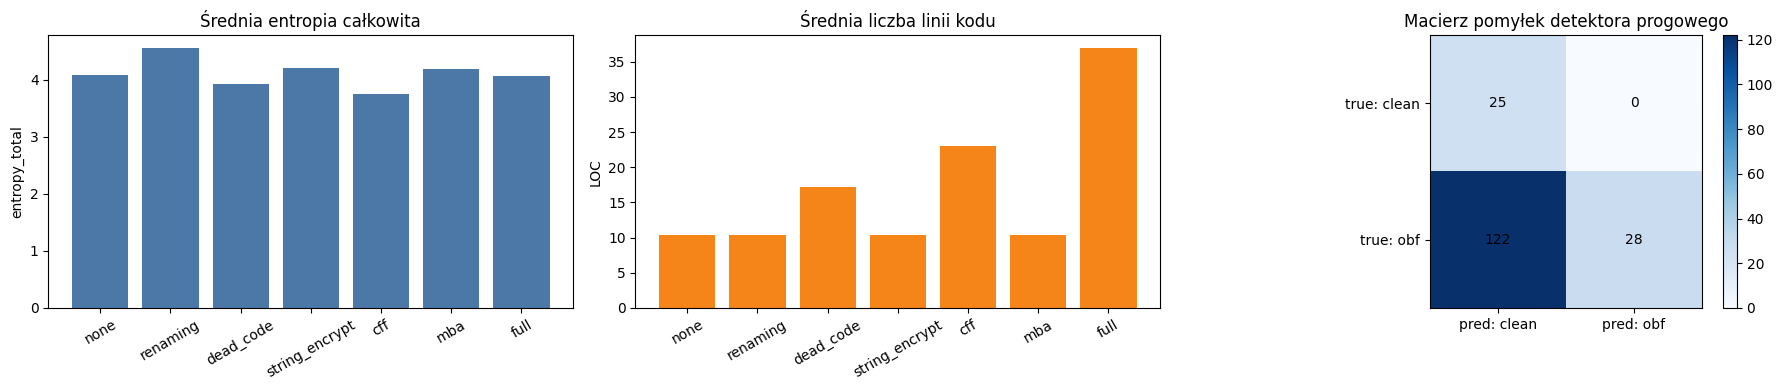

Detektor progowy: accuracy=0.303, precision=1.000, recall=0.187, F1=0.315


In [29]:
# ── Wizualizacje benchmarku ────────────────────────────────────────────────
techniques = [row['technique'] for row in benchmark_summary]
avg_entropy = [row['avg_entropy_total'] for row in benchmark_summary]
avg_loc = [row['avg_loc'] for row in benchmark_summary]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(techniques, avg_entropy, color='#4c78a8')
axes[0].set_title('Średnia entropia całkowita')
axes[0].set_ylabel('entropy_total')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(techniques, avg_loc, color='#f58518')
axes[1].set_title('Średnia liczba linii kodu')
axes[1].set_ylabel('LOC')
axes[1].tick_params(axis='x', rotation=30)

tp = sum(r['expected_obfuscated'] and r['detected'] for r in benchmark_rows)
tn = sum((not r['expected_obfuscated']) and (not r['detected']) for r in benchmark_rows)
fp = sum((not r['expected_obfuscated']) and r['detected'] for r in benchmark_rows)
fn = sum(r['expected_obfuscated'] and (not r['detected']) for r in benchmark_rows)
matrix = np.array([[tn, fp], [fn, tp]])
im = axes[2].imshow(matrix, cmap='Blues')
axes[2].set_title('Macierz pomyłek detektora progowego')
axes[2].set_xticks([0, 1], ['pred: clean', 'pred: obf'])
axes[2].set_yticks([0, 1], ['true: clean', 'true: obf'])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(matrix[i, j]), ha='center', va='center')
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

accuracy = (tp + tn) / max(1, tp + tn + fp + fn)
precision = tp / max(1, tp + fp)
recall = tp / max(1, tp + fn)
f1 = 2 * precision * recall / max(1e-9, precision + recall)
print(f'Detektor progowy: accuracy={accuracy:.3f}, precision={precision:.3f}, recall={recall:.3f}, F1={f1:.3f}')


---
## Wnioski z benchmarku

Benchmark pokazuje trzy rzeczy potrzebne do prezentacji projektu:

1. **Poprawność składniowa** — każdy wariant powinien przechodzić `compile`,
   bo `BaseObfuscator` weryfikuje wynik po transformacji.
2. **Poprawność semantyczna** — dla `bubble_sort`, `binary_search` i
   `caesar_encrypt` porównujemy wyniki przed i po obfuskacji na ustalonych
   przypadkach testowych.
3. **Koszt i skuteczność obfuskacji** — LOC, głębokość AST i entropia pokazują,
   które techniki najbardziej zmieniają kod. Macierz pomyłek pokazuje, gdzie
   prosty detektor progowy działa dobrze, a gdzie jest zbyt słaby.

To jest baza pod kolejny krok: rozszerzenie detektora o więcej cech statycznych
i klasyfikator ML, np. Random Forest lub Gradient Boosting.


# Etap 6, 7
Autorzy:  
Rafał Starypan, Eryk Mika, Kamil Wojcieszak

---

## Opis etapu 6

Szósty etap projektu rozszerza system o bardziej zaawansowaną detekcję obfuskacji
opartą na analizie statycznej kodu oraz klasyfikacji uczenia maszynowego.

W ramach etapu zaimplementowano:

### 1. Ekstrakcję cech statycznych kodu <a id='features'></a>
Analizowane są właściwości strukturalne programu, m.in.:

- liczba węzłów AST,
- liczba funkcji, klas, instrukcji warunkowych i pętli,
- liczba wywołań funkcji i przypisań,
- liczba stałych, stringów oraz operatorów,
- długość kodu, liczba linii i średnia długość identyfikatorów.

Pozwala to opisać kod numerycznie i wykrywać anomalie charakterystyczne
dla obfuskacji.

### 2. Klasyfikator ML do detekcji obfuskacji <a id='ml'></a>
Na podstawie wyekstrahowanych cech trenowany jest klasyfikator
`RandomForestClassifier`, który rozpoznaje czy próbka kodu została
poddana obfuskacji.

Model zwraca:
- predykcję klasy (`clean` / `obfuscated`),
- raport jakości klasyfikacji,
- macierz pomyłek oraz ważność cech.

### 3. Budowę zbioru treningowego <a id='dataset'></a>
Zbiór treningowy tworzony jest automatycznie przy pomocy generatora danych
z wcześniejszych etapów oraz pipeline'u obfuskacji.

Dzięki temu możliwe jest generowanie wielu wariantów tego samego programu
z różnymi technikami zaciemniania kodu.

### 4. Ewaluację i analizę ważności cech <a id='evaluation'></a>
Przeprowadzana jest ocena skuteczności modelu oraz ranking najbardziej
informatywnych cech wykorzystywanych do klasyfikacji.

### 5. Integrację z wcześniejszym interfejsem UI
Nowe metody detekcji zostały osadzone w istniejącym interfejsie `ipywidgets`
z etapu 4/5.

W zakładce **Detektor** użytkownik może teraz:
- uruchomić klasyczny detektor entropii,
- uruchomić detektor ML oparty o cechy statyczne,
- porównać wyniki obu metod,
- analizować metryki i raport klasyfikacji bez opuszczania panelu.


---


In [30]:
# ── Etap 6: ekstraktor cech + MLDetector ────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tokenize
from io import BytesIO


class StaticFeatureExtractor:
    """Ekstraktor cech statycznych kodu (~30 cech)."""

    @staticmethod
    def extract(source: str) -> dict:
        lines = source.splitlines()
        nonempty = [line for line in lines if line.strip()]
        total_chars = len(source)

        tree = ast.parse(source)
        names = []
        counts = {
            'nodes': 0, 'funcs': 0, 'classes': 0, 'returns': 0,
            'ifs': 0, 'fors': 0, 'whiles': 0, 'assigns': 0, 'calls': 0,
            'binops': 0, 'unaryops': 0, 'comparisons': 0,
            'constants': 0, 'str_constants': 0,
        }

        for node in ast.walk(tree):
            counts['nodes'] += 1
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
                counts['funcs'] += 1
            elif isinstance(node, ast.ClassDef):
                counts['classes'] += 1
            elif isinstance(node, ast.Return):
                counts['returns'] += 1
            elif isinstance(node, ast.If):
                counts['ifs'] += 1
            elif isinstance(node, ast.For):
                counts['fors'] += 1
            elif isinstance(node, ast.While):
                counts['whiles'] += 1
            elif isinstance(node, ast.Assign):
                counts['assigns'] += 1
            elif isinstance(node, ast.Call):
                counts['calls'] += 1
            elif isinstance(node, ast.BinOp):
                counts['binops'] += 1
            elif isinstance(node, ast.UnaryOp):
                counts['unaryops'] += 1
            elif isinstance(node, ast.Compare):
                counts['comparisons'] += 1
            elif isinstance(node, ast.Constant):
                counts['constants'] += 1
                if isinstance(node.value, str):
                    counts['str_constants'] += 1
            if isinstance(node, ast.Name):
                names.append(node.id)

        comment_tokens = 0
        string_tokens = 0
        try:
            tokens = tokenize.tokenize(BytesIO(source.encode('utf-8')).readline)
            for toknum, tokval, _, _, _ in tokens:
                if toknum == tokenize.COMMENT:
                    comment_tokens += 1
                elif toknum == tokenize.STRING:
                    string_tokens += 1
        except tokenize.TokenError:
            pass

        unique_names = set(names)
        return {
            'num_chars': total_chars,
            'num_lines': len(lines),
            'nonempty_lines': len(nonempty),
            'avg_line_len': sum(len(line) for line in lines) / max(1, len(lines)),
            'blank_line_ratio': sum(1 for line in lines if not line.strip()) / max(1, len(lines)),
            'non_alnum_ratio': sum(1 for c in source if not c.isalnum() and not c.isspace()) / max(1, total_chars),
            'total_entropy': EntropyDetector.shannon_entropy(source),
            'line_entropy': EntropyDetector.line_entropy(source),
            'identifier_entropy': EntropyDetector.identifier_entropy(source),
            'ast_depth': _ast_depth(tree),
            'num_ast_nodes': counts['nodes'],
            'num_functions': counts['funcs'],
            'num_classes': counts['classes'],
            'num_returns': counts['returns'],
            'num_ifs': counts['ifs'],
            'num_fors': counts['fors'],
            'num_whiles': counts['whiles'],
            'num_assigns': counts['assigns'],
            'num_calls': counts['calls'],
            'num_binops': counts['binops'],
            'num_unaryops': counts['unaryops'],
            'num_comparisons': counts['comparisons'],
            'num_constants': counts['constants'],
            'num_string_constants': counts['str_constants'],
            'string_constant_ratio': counts['str_constants'] / max(1, counts['constants']),
            'num_names': len(names),
            'num_unique_names': len(unique_names),
            'unique_name_ratio': len(unique_names) / max(1, len(names)),
            'avg_name_length': sum(len(n) for n in names) / max(1, len(names)),
            'comment_ratio': comment_tokens / max(1, len(lines)),
            'string_token_ratio': string_tokens / max(1, len(lines)),
        }


class MLDetector:
    """Klasyfikator RF do wykrywania obfuskacji (z balansem klas)."""

    def __init__(self, model=None, scaler=None):
        self.model = model or RandomForestClassifier(
            n_estimators=200, random_state=42, n_jobs=-1,
            class_weight='balanced')
        self.scaler = scaler or StandardScaler()
        self.features = []

    def fit(self, sources: list, labels: list):
        feature_dicts = [StaticFeatureExtractor.extract(src) for src in sources]
        self.features = sorted(feature_dicts[0].keys())
        X = np.array([[fd[f] for f in self.features] for fd in feature_dicts],
                     dtype=float)
        self.scaler.fit(X)
        self.model.fit(self.scaler.transform(X), labels)

    def _to_X(self, sources: list) -> np.ndarray:
        feature_dicts = [StaticFeatureExtractor.extract(src) for src in sources]
        X = np.array([[fd[f] for f in self.features] for fd in feature_dicts],
                     dtype=float)
        return self.scaler.transform(X)

    def predict(self, sources: list) -> np.ndarray:
        return self.model.predict(self._to_X(sources))

    def predict_proba(self, sources: list) -> np.ndarray:
        return self.model.predict_proba(self._to_X(sources))

    def feature_importances(self) -> list:
        return sorted(zip(self.features, self.model.feature_importances_),
                      key=lambda item: item[1], reverse=True)


print('StaticFeatureExtractor i MLDetector zdefiniowane.')


StaticFeatureExtractor i MLDetector zdefiniowane.


In [31]:
# ── Zbalansowany dataset + trening ───────────────────────────────────────────
import random as _rand_etap6

# 1. Próbki czyste: 5 z TEST_SAMPLES + 4×25 z generatora (różne seedy) = 105
clean_sources = list(TEST_SAMPLES.values())
for _seed in [42, 99, 7, 123]:
    clean_sources.extend(CodeGenerator(seed=_seed).generate_batch(25).values())

# 2. Pipeline'y do generowania obfuskowanych próbek (5 technik + full = 6)
ml_pipelines_for_obf = {k: v for k, v in BENCHMARK_PIPELINES.items()
                        if v is not None}
techniques_cycle = list(ml_pipelines_for_obf.keys())

# 3. Każdą czystą obfuskujemy jedną techniką (cykliczne dla równego rozkładu)
ml_sources = list(clean_sources)
ml_labels = [0] * len(ml_sources)

for i, source in enumerate(clean_sources):
    technique = techniques_cycle[i % len(techniques_cycle)]
    order = ml_pipelines_for_obf[technique]
    cfg = _variant_config(order, seed=42)
    try:
        obf = build_pipeline(cfg).run(source)
        ml_sources.append(obf)
        ml_labels.append(1)
    except Exception as e:
        # Pomiń próbkę jeśli obfuskacja się wywaliła (np. CFF na nietypowej składni)
        pass

n_clean = sum(1 for x in ml_labels if x == 0)
n_obf = sum(1 for x in ml_labels if x == 1)
print(f'Dataset: {len(ml_sources)} próbek '
      f'({n_clean} clean, {n_obf} obf, ratio 1:{n_obf/max(1, n_clean):.2f})')

# 4. Train/test split ze stratyfikacją
X_train, X_test, y_train, y_test = train_test_split(
    ml_sources, ml_labels, test_size=0.2, random_state=42, stratify=ml_labels)
print(f'Train: {len(X_train)} (clean: {sum(1 for x in y_train if x == 0)}, '
      f'obf: {sum(1 for x in y_train if x == 1)})')
print(f'Test:  {len(X_test)} (clean: {sum(1 for x in y_test if x == 0)}, '
      f'obf: {sum(1 for x in y_test if x == 1)})')

# 5. Trening
ml_detector = MLDetector()
ml_detector.fit(X_train, y_train)
y_pred = ml_detector.predict(X_test)

# 6. 5-fold CV na pełnym zbiorze treningowym (mean ± std)
from sklearn.model_selection import cross_val_score
ml_X_train_features = ml_detector._to_X(X_train)
cv_scores = cross_val_score(ml_detector.model, ml_X_train_features, y_train,
                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                            scoring='f1_weighted')
print(f'\n5-fold CV F1-weighted: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

print('\n=== Klasyfikacja na test set ===')
print(classification_report(y_test, y_pred, target_names=['clean', 'obfuscated']))

print('Macierz pomyłek (wiersze = prawda, kolumny = predykcja):')
cm = confusion_matrix(y_test, y_pred)
print(cm)

print('\nNajważniejsze cechy (top 12):')
for name, importance in ml_detector.feature_importances()[:12]:
    print(f'  {name:30s} {importance:.4f}')


Dataset: 210 próbek (105 clean, 105 obf, ratio 1:1.00)
Train: 168 (clean: 84, obf: 84)
Test:  42 (clean: 21, obf: 21)



5-fold CV F1-weighted: 0.857 ± 0.034

=== Klasyfikacja na test set ===
              precision    recall  f1-score   support

       clean       0.89      0.81      0.85        21
  obfuscated       0.83      0.90      0.86        21

    accuracy                           0.86        42
   macro avg       0.86      0.86      0.86        42
weighted avg       0.86      0.86      0.86        42

Macierz pomyłek (wiersze = prawda, kolumny = predykcja):
[[17  4]
 [ 2 19]]

Najważniejsze cechy (top 12):
  identifier_entropy             0.1246
  total_entropy                  0.0999
  line_entropy                   0.0800
  num_chars                      0.0793
  string_constant_ratio          0.0710
  avg_name_length                0.0685
  non_alnum_ratio                0.0683
  num_constants                  0.0637
  avg_line_len                   0.0596
  num_whiles                     0.0383
  num_ifs                        0.0338
  num_ast_nodes                  0.0332


### Wizualizacje ML
4 wykresy w `subplots(2, 2)`: top-15 cech, ROC, PR, macierz pomyłek.


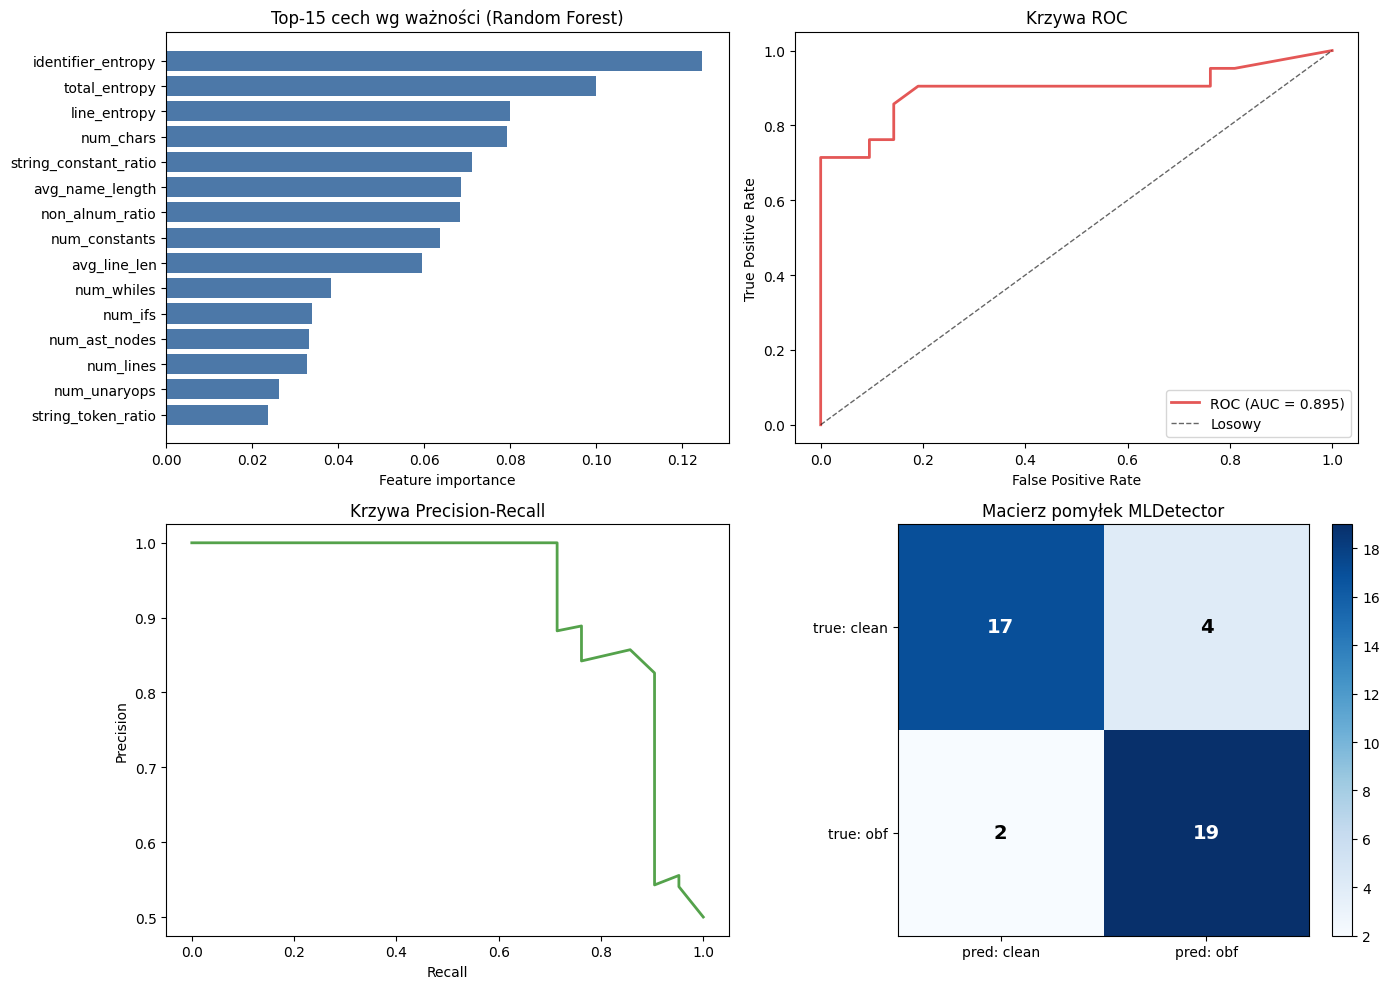


ROC-AUC: 0.895


In [32]:
# ── Wizualizacje ML detektora ────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Top-15 cech
top_features = ml_detector.feature_importances()[:15]
fnames = [f for f, _ in top_features][::-1]
fvals = [imp for _, imp in top_features][::-1]
axes[0, 0].barh(fnames, fvals, color='#4c78a8')
axes[0, 0].set_title('Top-15 cech wg ważności (Random Forest)')
axes[0, 0].set_xlabel('Feature importance')

# 2. ROC curve
y_pred_proba = ml_detector.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='#e45756', lw=2,
                label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Losowy')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('Krzywa ROC')
axes[0, 1].legend(loc='lower right')

# 3. PR curve
precision_arr, recall_arr, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1, 0].plot(recall_arr, precision_arr, color='#54a24b', lw=2)
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Krzywa Precision-Recall')

# 4. Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
im = axes[1, 1].imshow(cm, cmap='Blues')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_xticklabels(['pred: clean', 'pred: obf'])
axes[1, 1].set_yticklabels(['true: clean', 'true: obf'])
for i in range(2):
    for j in range(2):
        axes[1, 1].text(j, i, str(cm[i, j]), ha='center', va='center',
                        color='white' if cm[i, j] > cm.max()/2 else 'black',
                        fontsize=14, fontweight='bold')
axes[1, 1].set_title('Macierz pomyłek MLDetector')
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f'\nROC-AUC: {roc_auc:.3f}')


### Porównanie detektora ML vs progowego
Oba detektory ewaluowane na tym samym `X_test`. Cel: pokazać przewagę
ML nad detektorem progowym.


Metryka      |    Progowy |    ML (RF) |          Δ
--------------------------------------------------
accuracy     |      0.619 |      0.857 |     +0.238
precision    |      1.000 |      0.826 |     -0.174
recall       |      0.238 |      0.905 |     +0.667
f1           |      0.385 |      0.864 |     +0.479


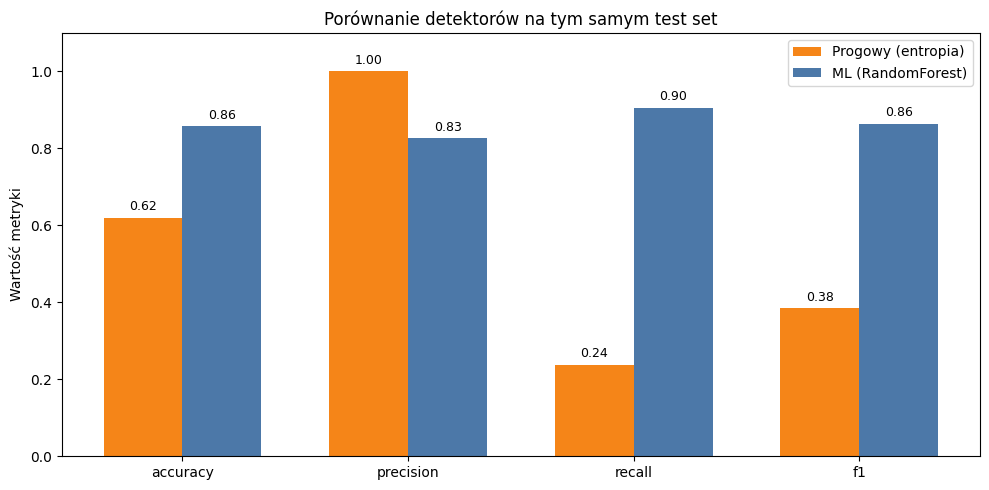

In [33]:
# ── Porównanie detektorów: progowy vs ML ────────────────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

threshold_det = EntropyDetector()
default_th = default_config()['detector']['thresholds']


def threshold_predict(sources):
    preds = []
    for src in sources:
        try:
            r = threshold_det.analyze(src)
            preds.append(int(
                r['total_entropy'] >= default_th['total_entropy'] or
                r['identifier_entropy'] >= default_th['identifier_entropy']))
        except Exception:
            preds.append(0)
    return preds


def metrics_for(y_true, y_pred):
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }


threshold_preds = threshold_predict(X_test)
ml_preds = ml_detector.predict(X_test)

m_thr = metrics_for(y_test, threshold_preds)
m_ml = metrics_for(y_test, ml_preds)

print(f'{"Metryka":<12s} | {"Progowy":>10s} | {"ML (RF)":>10s} | {"Δ":>10s}')
print('-' * 50)
for k in ['accuracy', 'precision', 'recall', 'f1']:
    print(f'{k:<12s} | {m_thr[k]:>10.3f} | {m_ml[k]:>10.3f} | '
          f'{m_ml[k] - m_thr[k]:>+10.3f}')

# Bar chart
metric_names = ['accuracy', 'precision', 'recall', 'f1']
thr_vals = [m_thr[m] for m in metric_names]
ml_vals  = [m_ml[m]  for m in metric_names]

fig_cmp, ax_cmp = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(metric_names))
width = 0.35
ax_cmp.bar(x_pos - width/2, thr_vals, width, label='Progowy (entropia)', color='#f58518')
ax_cmp.bar(x_pos + width/2, ml_vals, width, label='ML (RandomForest)', color='#4c78a8')
ax_cmp.set_xticks(x_pos)
ax_cmp.set_xticklabels(metric_names)
ax_cmp.set_ylim(0, 1.1)
ax_cmp.set_ylabel('Wartość metryki')
ax_cmp.set_title('Porównanie detektorów na tym samym test set')
ax_cmp.legend()
for i, (t, m) in enumerate(zip(thr_vals, ml_vals)):
    ax_cmp.text(i - width/2, t + 0.02, f'{t:.2f}', ha='center', fontsize=9)
    ax_cmp.text(i + width/2, m + 0.02, f'{m:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


### Per-variant recall
Świeże próbki obfuskowane z `seed=99` (out-of-distribution).
Pokazuje, które techniki obfuskacji są najtrudniejsze do wykrycia.


Per-variant recall (seed=99 — out-of-distribution względem treningu):
Technika               Recall     N
------------------------------------
renaming               100.0%    30
dead_code              100.0%    30
full                   100.0%    30
cff                     93.3%    30
mba                     83.3%    30
string_encrypt          46.7%    30


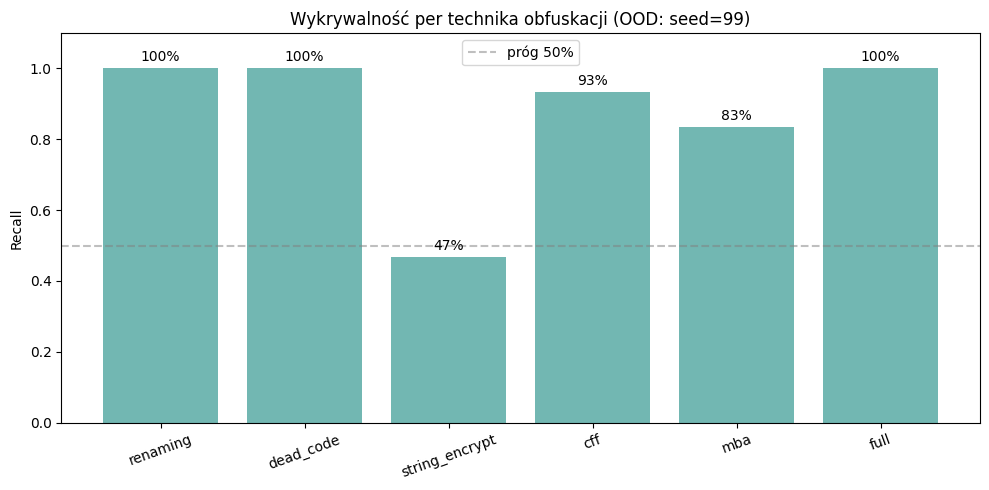

In [34]:
# ── Per-variant recall (out-of-distribution: seed=99) ────────────────────────

# Generujemy świeże próbki obfuskowane (seed 99 — różne od treningu seed=42)
recall_per_variant = {}
test_clean_subset = clean_sources[:30]  # podzbiór do oceny

for technique, order in ml_pipelines_for_obf.items():
    correct = 0
    total = 0
    for source in test_clean_subset:
        cfg = _variant_config(order, seed=99)  # OOD seed
        try:
            obf = build_pipeline(cfg).run(source)
            pred = ml_detector.predict([obf])[0]
            if pred == 1:
                correct += 1
            total += 1
        except Exception:
            pass
    if total > 0:
        recall_per_variant[technique] = correct / total

print('Per-variant recall (seed=99 — out-of-distribution względem treningu):')
print(f'{"Technika":<20s} {"Recall":>8s} {"N":>5s}')
print('-' * 36)
for technique, recall in sorted(recall_per_variant.items(),
                                 key=lambda x: -x[1]):
    print(f'{technique:<20s} {recall*100:>7.1f}% {30:>5d}')

# Bar chart
fig_pv, ax_pv = plt.subplots(figsize=(10, 5))
techs = list(recall_per_variant.keys())
recalls = [recall_per_variant[t] for t in techs]
ax_pv.bar(techs, recalls, color='#72b7b2')
ax_pv.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5,
              label='próg 50%')
ax_pv.set_ylim(0, 1.1)
ax_pv.set_ylabel('Recall')
ax_pv.set_title('Wykrywalność per technika obfuskacji (OOD: seed=99)')
ax_pv.legend()
plt.xticks(rotation=20)
for i, r in enumerate(recalls):
    ax_pv.text(i, r + 0.02, f'{r*100:.0f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Persystencja modelu
Zapis wytrenowanego modelu do pliku przez `joblib`. Ostrzeżenie przy
mismatch wersji `sklearn`. Round-trip smoke test.


In [35]:
# ── Persystencja modelu (joblib) ─────────────────────────────────────────────
import joblib
import sklearn


def save_ml_detector(detector, path):
    """Zapisuje wytrenowany MLDetector do pliku joblib."""
    payload = {
        'model': detector.model,
        'scaler': detector.scaler,
        'features': detector.features,
        'sklearn_version': sklearn.__version__,
    }
    joblib.dump(payload, path)
    print(f'Zapisano model do: {path}')


def load_ml_detector(path):
    """Wczytuje MLDetector z pliku joblib."""
    payload = joblib.load(path)
    if payload['sklearn_version'] != sklearn.__version__:
        print(f'OSTRZEŻENIE: model trenowany na sklearn '
              f'{payload["sklearn_version"]}, '
              f'aktualnie {sklearn.__version__}')
    detector = MLDetector(model=payload['model'], scaler=payload['scaler'])
    detector.features = payload['features']
    return detector


# Smoke test: zapis -> odczyt -> predykcje zgodne
save_ml_detector(ml_detector, 'ml_detector.joblib')
loaded_detector = load_ml_detector('ml_detector.joblib')

_test_clean = TEST_SAMPLES['bubble_sort']
_test_obf = build_pipeline(_variant_config(['renaming'], seed=42)).run(_test_clean)

assert ml_detector.predict([_test_clean])[0] == loaded_detector.predict([_test_clean])[0]
assert ml_detector.predict([_test_obf])[0] == loaded_detector.predict([_test_obf])[0]
print('Persystencja modelu działa: predykcje przed/po zapisie zgodne.')


Zapisano model do: ml_detector.joblib


Persystencja modelu działa: predykcje przed/po zapisie zgodne.


---
# Etap 7 — finalizacja etapu 6 + 5. obfuskator (MBA) <a id='etap7'></a>

W etapie 7 zrealizowano cztery porządkujące zmiany:

1. **5. obfuskator MBA** (Mixed Boolean-Arithmetic) — zamiana literałów
   całkowitych na wyrażenia arytmetyczno-bitowe. Domyślnie włączony
   w pipeline (sekcja 6.5 powyżej).
2. **Balansowanie zbioru ML** — z 1:5 do 1:1, użyto 4 seedów generatora
   i równomiernego rozkładu 6 technik na próbki obfuskowane.
   `class_weight='balanced'` dorzucone jako safety net.
3. **Wizualizacje + porównanie + per-variant + persystencja** — komórki
   `etap6-plots-ml`, `etap6-compare-detectors`, `etap6-per-variant-recall`,
   `etap6-persistence` (powyżej).
4. **Integracja MLDetector w UI** — zakładka *Detektor* ma teraz
   3 tryby (`Progowy / ML / Oba`) i pozwala wczytać model z pliku.


In [36]:
# ── Świeży UI z trybami detektora (po treningu ML) ──────────────────────────
ui_etap7 = make_ui()
display(ui_etap7)


### Plan dalszego rozwoju
- Real-world samples (kod ze stdlib / PyPI) — pokazałoby FP rate na realnym kodzie.
- Adwersarialny obfuskator został przeniesiony do etapu 8 poniżej.


---
# Etap 8 — adwersarialny obfuskator unikający ML detektora <a id='etap8'></a>

Celem etapu 8 jest sprawdzenie słabości detektora ML z etapu 6.
Zamiast maksymalnie zwiększać złożoność kodu, obfuskator generuje kilka
wariantów i wybiera ten, który ma najniższe prawdopodobieństwo klasy
`obfuscated` według `MLDetector`.

To jest wariant **adwersarialny**: nadal wykonuje semantycznie neutralne
transformacje, ale optymalizuje je pod aktualny detektor.

Strategie kandydatów:
- `natural_names` — zamiana nazw na krótkie, naturalne identyfikatory
- `mba_low` — lekkie MBA na literałach całkowitych
- `dead_code_low` — mała dawka martwego kodu
- `string_encrypt_low` — szyfrowanie tylko dłuższych stringów

Ważne: to nie jest uniwersalne obejście wszystkich detektorów. To pokazuje,
że model trenowany na znanych wariantach obfuskacji można aktywnie omijać,
jeśli atakujący ma dostęp do jego predykcji.


In [37]:
# ── Etap 8: adwersarialny obfuskator ───────────────────────────────────────


class _AdversarialNameTransformer(ast.NodeTransformer):
    """Zmienia identyfikatory na naturalnie wyglądające nazwy."""

    def __init__(self, mapping: dict):
        self._m = mapping

    def visit_Name(self, node):
        node.id = self._m.get(node.id, node.id)
        return node

    def visit_arg(self, node):
        node.arg = self._m.get(node.arg, node.arg)
        return node

    def visit_FunctionDef(self, node):
        node.name = self._m.get(node.name, node.name)
        self.generic_visit(node)
        return node

    visit_AsyncFunctionDef = visit_FunctionDef

    def visit_ClassDef(self, node):
        node.name = self._m.get(node.name, node.name)
        self.generic_visit(node)
        return node


class AdversarialObfuscator(BaseObfuscator):
    """Obfuskator wybierający wariant najmniej podejrzany dla MLDetector."""

    TECHNIQUES = ['natural_names', 'mba_low', 'dead_code_low', 'string_encrypt_low']

    def __init__(self, detector_name='ml_detector', attempts=24,
                 target_probability=0.5, max_growth=6.0,
                 candidate_pool=None, seed=None):
        self.detector_name = detector_name
        self.attempts = attempts
        self.target_probability = target_probability
        self.max_growth = max_growth
        self.candidate_pool = list(candidate_pool or self.TECHNIQUES[:3])
        self.seed = seed
        self.history = []

    def _transform(self, tree: ast.AST) -> ast.AST:
        return tree

    def obfuscate(self, source: str) -> str:
        if not BaseObfuscator._verify(source):
            raise SyntaxError('Kod wejściowy nie jest poprawny składniowo.')

        rng = random.Random(self.seed) if self.seed is not None else random.Random()
        detector = globals().get(self.detector_name)
        best_source = None
        best_score = float('inf')
        self.history = []

        for _ in range(self.attempts):
            order = self._candidate_order(rng)
            candidate = source
            try:
                for technique in order:
                    candidate = self._apply_technique(technique, candidate, rng)
            except Exception:
                continue

            if not BaseObfuscator._verify(candidate):
                continue
            if len(candidate) / max(1, len(source)) > self.max_growth:
                continue

            score, detected = self._score_candidate(candidate, detector)
            self.history.append({
                'order': order,
                'p_obf': round(score, 4),
                'detected': detected,
                'chars': len(candidate),
            })

            if score < best_score and candidate != source:
                best_source = candidate
                best_score = score
            if best_source is not None and best_score <= self.target_probability:
                break

        if best_source is not None:
            return best_source
        return self._naturalize_identifiers(source)

    def _candidate_order(self, rng):
        pool = [t for t in self.candidate_pool if t in self.TECHNIQUES]
        if not pool:
            pool = ['natural_names']
        count = rng.randint(1, min(3, len(pool)))
        order = rng.sample(pool, count)
        if 'natural_names' in order:
            order.remove('natural_names')
            order.insert(0, 'natural_names')
        return order

    def _apply_technique(self, technique, source, rng):
        seed = rng.randint(0, 1_000_000)
        if technique == 'natural_names':
            return self._naturalize_identifiers(source)
        if technique == 'mba_low':
            return MBAObfuscator(seed=seed, apply_probability=0.35,
                                 expression_depth=1).obfuscate(source)
        if technique == 'dead_code_low':
            return DeadCodeInserter(insertion_probability=0.12,
                                    max_insertions=1,
                                    templates=['dead_if', 'dead_for'],
                                    seed=seed).obfuscate(source)
        if technique == 'string_encrypt_low':
            return StringEncryptor(seed=seed, skip_docstrings=True,
                                   min_string_length=8).obfuscate(source)
        return source

    def _score_candidate(self, source, detector):
        if detector is not None and hasattr(detector, 'predict_proba'):
            try:
                proba = float(detector.predict_proba([source])[0][1])
                detected = bool(detector.predict([source])[0])
                return proba, detected
            except Exception:
                pass

        entropy = EntropyDetector().analyze(source)
        fallback = (entropy['total_entropy'] / 8 +
                    entropy['identifier_entropy'] / 8) / 2
        return min(1.0, max(0.0, fallback)), None

    def _naturalize_identifiers(self, source):
        tree = ast.parse(source)
        collector = _NameCollector()
        collector.visit(tree)

        var_pool = ['data', 'items', 'value', 'index', 'count', 'result',
                    'left', 'right', 'total', 'text', 'key', 'item']
        func_pool = ['process', 'calculate', 'transform', 'search', 'sort_items']
        cls_pool = ['Processor', 'Container', 'Result', 'Model']
        used = set(PROTECTED_NAMES)
        mapping = {}

        def take_name(pool, idx):
            n = idx
            while True:
                base = pool[n % len(pool)]
                name = base if n < len(pool) else f'{base}_{n // len(pool)}'
                if name not in used:
                    used.add(name)
                    return name
                n += 1

        for i, old in enumerate(sorted(collector.vars - PROTECTED_NAMES)):
            mapping[old] = take_name(var_pool, i)
        for i, old in enumerate(sorted(collector.funcs - PROTECTED_NAMES)):
            mapping[old] = take_name(func_pool, i)
        for i, old in enumerate(sorted(collector.classes - PROTECTED_NAMES)):
            mapping[old] = take_name(cls_pool, i)

        tree = _AdversarialNameTransformer(mapping).visit(tree)
        ast.fix_missing_locations(tree)
        return ast.unparse(tree)


print('AdversarialObfuscator zdefiniowany.')


AdversarialObfuscator zdefiniowany.


In [38]:
# ── Integracja Etapu 8 z konfiguracją, pipeline'em i UI ─────────────────────

PARAM_SCHEMA['adversarial'] = {
    'detector_name': {
        'type': 'str', 'default': 'ml_detector',
        'label': 'Nazwa globalnego detektora ML'},
    'attempts': {
        'type': 'int', 'min': 1, 'max': 100, 'default': 24,
        'label': 'Liczba prób kandydatów'},
    'target_probability': {
        'type': 'float', 'min': 0.0, 'max': 1.0, 'step': 0.05,
        'default': 0.5, 'label': 'Cel p_obf poniżej'},
    'max_growth': {
        'type': 'float', 'min': 1.0, 'max': 20.0, 'step': 0.5,
        'default': 6.0, 'label': 'Maks. wzrost rozmiaru'},
    'candidate_pool': {
        'type': 'multiselect',
        'choices': AdversarialObfuscator.TECHNIQUES,
        'default': ['natural_names', 'mba_low', 'dead_code_low'],
        'label': 'Strategie kandydatów'},
    'seed': {'type': 'int?', 'default': None, 'label': 'Seed'},
}

OBFUSCATOR_CLASSES['adversarial'] = AdversarialObfuscator
OBFUSCATOR_LABELS['adversarial'] = 'Adversarial (unikanie ML)'

_cfg8 = default_config()
assert 'adversarial' in _cfg8['obfuscators']
assert not validate_config(_cfg8)
_cfg8_adv = default_config()
_cfg8_adv['pipeline'] = ['adversarial']
assert isinstance(build_pipeline(_cfg8_adv), ObfuscationPipeline)
print('Etap 8 podłączony do PARAM_SCHEMA, build_pipeline() i UI.')


Etap 8 podłączony do PARAM_SCHEMA, build_pipeline() i UI.


In [39]:
# ── Demo: porównanie pełnego pipeline'u z obfuskacją adwersarialną ─────────

def _ml_verdict(detector, source):
    if detector is None:
        return 'niedostępny', None
    try:
        pred = bool(detector.predict([source])[0])
        proba = float(detector.predict_proba([source])[0][1])
        return ('obfuscated' if pred else 'clean'), proba
    except Exception as e:
        return f'błąd: {e}', None


_adv_source = TEST_SAMPLES['bubble_sort']
_full_cfg = _variant_config(['string_encrypt', 'mba', 'dead_code', 'cff', 'renaming'],
                           seed=77)
_full_obf = build_pipeline(_full_cfg).run(_adv_source)

_adv = AdversarialObfuscator(seed=77, attempts=32, target_probability=0.5)
_adv_obf = _adv.obfuscate(_adv_source)

_det = globals().get('ml_detector')
_rows = [
    ('oryginał', _adv_source),
    ('pełny pipeline', _full_obf),
    ('adversarial', _adv_obf),
]

print(f'{"Wariant":<16s} {"Decyzja ML":<14s} {"p_obf":>8s} {"Znaki":>8s}')
print('-' * 52)
for label, code in _rows:
    verdict, proba = _ml_verdict(_det, code)
    p_txt = '-' if proba is None else f'{proba:.3f}'
    print(f'{label:<16s} {verdict:<14s} {p_txt:>8s} {len(code):>8d}')

print('\nNajlepsze próby adversarialne:')
for item in sorted(_adv.history, key=lambda x: x['p_obf'])[:5]:
    print(f"  p_obf={item['p_obf']:.4f}, detected={item['detected']}, "
          f"order={item['order']}, chars={item['chars']}")

assert BaseObfuscator._verify(_adv_obf)
assert differential_test(_adv_source, _adv_obf, CONTRACTS['bubble_sort'])
print('\nAdversarialObfuscator: składnia i semantyka bubble_sort zachowane.')


Wariant          Decyzja ML        p_obf    Znaki
----------------------------------------------------
oryginał         clean             0.235      240


pełny pipeline   obfuscated        0.995     1011
adversarial      clean             0.345      251

Najlepsze próby adversarialne:
  p_obf=0.3450, detected=False, order=['mba_low'], chars=251
  p_obf=0.7550, detected=True, order=['natural_names', 'mba_low'], chars=326

AdversarialObfuscator: składnia i semantyka bubble_sort zachowane.


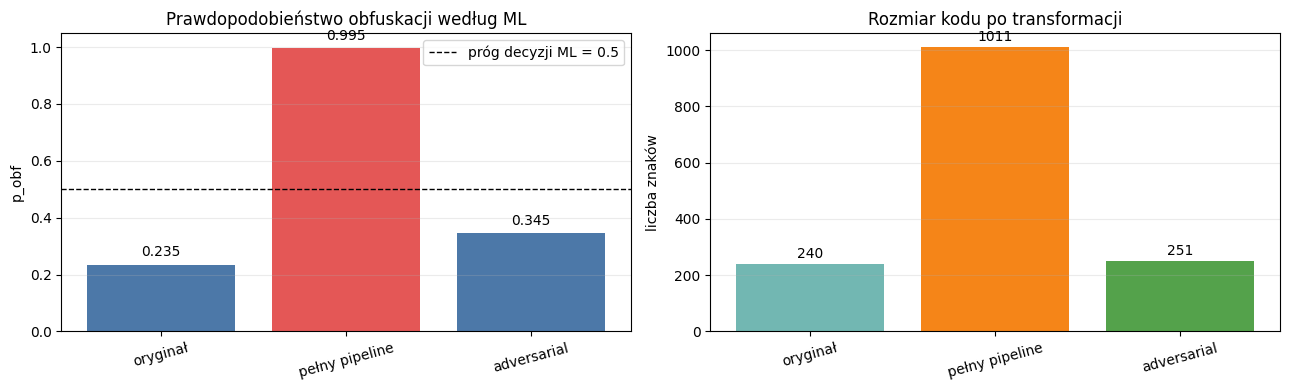

Tabela wyników:
Wariant          Decyzja ML        p_obf    Znaki
----------------------------------------------------
oryginał         clean             0.235      240
pełny pipeline   obfuscated        0.995     1011
adversarial      clean             0.345      251


In [40]:
# ── Etap 8: wykresy wyników do prezentacji ────────────────────────────────

_plot_labels = [label for label, _ in _rows]
_plot_probabilities = []
_plot_sizes = []
_plot_decisions = []

for label, code in _rows:
    verdict, proba = _ml_verdict(_det, code)
    _plot_probabilities.append(proba if proba is not None else 0.0)
    _plot_sizes.append(len(code))
    _plot_decisions.append(verdict)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

prob_colors = ['#4C78A8' if p < 0.5 else '#E45756'
               for p in _plot_probabilities]
axes[0].bar(_plot_labels, _plot_probabilities, color=prob_colors)
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1,
                label='próg decyzji ML = 0.5')
axes[0].set_title('Prawdopodobieństwo obfuskacji według ML')
axes[0].set_ylabel('p_obf')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
for i, p in enumerate(_plot_probabilities):
    axes[0].text(i, p + 0.03, f'{p:.3f}', ha='center')

axes[1].bar(_plot_labels, _plot_sizes,
            color=['#72B7B2', '#F58518', '#54A24B'])
axes[1].set_title('Rozmiar kodu po transformacji')
axes[1].set_ylabel('liczba znaków')
for i, size in enumerate(_plot_sizes):
    axes[1].text(i, size + max(_plot_sizes) * 0.02, str(size),
                 ha='center')

for ax in axes:
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

print('Tabela wyników:')
print(f'{"Wariant":<16s} {"Decyzja ML":<14s} {"p_obf":>8s} {"Znaki":>8s}')
print('-' * 52)
for label, decision, p, size in zip(_plot_labels, _plot_decisions,
                                    _plot_probabilities, _plot_sizes):
    print(f'{label:<16s} {decision:<14s} {p:>8.3f} {size:>8d}')


### Wnioski z etapu 8
- Detektor ML działa dobrze na rozkładzie podobnym do treningowego, ale jest podatny na aktywne szukanie wariantów o niskim `p_obf`.
- Najprostsza obrona to rozszerzenie treningu o próbki adwersarialne i walidacja na danych spoza rozkładu treningowego.
- UI nie jest potrzebny do prezentacji etapu 8; pokazujemy wykresy i tabelę wyników.



# Etap 9 — Predykaty nieprzezroczyste (Opaque Predicates)
Autorzy: Rafał Starypan, Eryk Mika, Kamil Wojcieszak

## Algorytm 6 — Predykaty nieprzezroczyste (Opaque Predicates)

### Opis
Predykaty nieprzezroczyste to warunki o **algebraicznie ustalonym wyniku**
(zawsze True lub zawsze False), których poprawność jest trudna do ustalenia
przez analizę statyczną bez pełnej dedukcji arytmetycznej.

Różnica wobec `dead_if` z etapu 2:
- `if False:` — wynik znany bezpośrednio z literału
- `if n * (n + 1) % 2 == 0:` — wymaga wiedzy o arytmetyce całkowitej

### Baza matematyczna
Używamy niezmienników liczb całkowitych:

| Predykat | Zawsze | Uzasadnienie |
|---|---|---|
| `n*(n+1) % 2 == 0` | True | iloczyn dwóch kolejnych liczb jest parzyste |
| `n*n + n >= n` | True | n²+n ≥ n ⟺ n² ≥ 0 |
| `(a \| b) >= 0` | True (dla n≥0) | OR bitowy nie zmniejsza wartości |
| `(a & ~a) == 0` | True | AND liczby i jej dopełnienia = 0 |
| `n*n*n - n ≡ 0 (mod 6)` | True | dla każdej liczby całkowitej |
| `(2*n + 1) % 2 == 1` | True | 2k+1 jest zawsze nieparzyste |

### Strategia
1. Przejście po AST — lokalizacja `FunctionDef` i ich ciał
2. Wylistowanie nazw zmiennych całkowitych dostępnych w scope
3. Wstrzyknięcie w losowe miejsca ciała instrukcji `if <predykat>: <dead_body>`
   lub `if not <predykat>: <dead_body>` (never executed)
4. Opcjonalnie: zawijanie istniejących bloków w `if <predykat_zawsze_true>:`
   (semantycznie neutralne, strukturalnie mylące)

**Parametry:**
- `injection_probability` — p wstrzyknięcia przed/po każdej instrukcji
- `wrap_probability` — p zawijania bloku w zawsze-True predykat
- `use_scope_vars` — czy używać zmiennych z lokalnego scope do predykatów
- `seed`

In [41]:
# ── Etap 9: OpaquePredicateInserter ─────────────────────────────────────────

class _OpaquePredicateTransformer(ast.NodeTransformer):
    """Wstrzykuje predykaty nieprzezroczyste w ciała funkcji."""

    def __init__(self, rng: random.Random,
                 injection_probability: float,
                 wrap_probability: float,
                 use_scope_vars: bool):
        self._rng = rng
        self._p_inject = injection_probability
        self._p_wrap = wrap_probability
        self._use_scope_vars = use_scope_vars

    # ── Budowanie predykatów ─────────────────────────────────────────────────

    def _make_always_true(self, scope_names: list) -> ast.expr:
        """Predykaty oparte wyłącznie na stałych całkowitych — brak ryzyka TypeError."""
        strategies = [
            self._pred_n_n1_mod2,
            self._pred_nsq_plus_n,
            self._pred_double_plus1,
            self._pred_and_complement,
        ]
        # Losowa stała całkowita — predykat wygląda jak operacja na liczbie,
        # nie jak literał False, więc jest nadal nieprzezroczysty statycznie
        val = self._rng.randint(2, 999)
        var_node = ast.Constant(value=val)
        return self._rng.choice(strategies)(var_node)

    @staticmethod
    def _pred_n_n1_mod2(n: ast.expr) -> ast.expr:
        """n*(n+1) % 2 == 0  — zawsze True dla n ∈ ℤ."""
        n_plus_1 = ast.BinOp(left=n, op=ast.Add(), right=ast.Constant(value=1))
        product = ast.BinOp(left=n, op=ast.Mult(), right=n_plus_1)
        mod2 = ast.BinOp(left=product, op=ast.Mod(), right=ast.Constant(value=2))
        return ast.Compare(left=mod2, ops=[ast.Eq()],
                           comparators=[ast.Constant(value=0)])

    @staticmethod
    def _pred_nsq_plus_n(n: ast.expr) -> ast.expr:
        """n*n + n >= n  — zawsze True (n²≥0)."""
        nsq = ast.BinOp(left=n, op=ast.Mult(), right=n)
        nsq_plus_n = ast.BinOp(left=nsq, op=ast.Add(), right=n)
        return ast.Compare(left=nsq_plus_n, ops=[ast.GtE()],
                           comparators=[n])

    @staticmethod
    def _pred_double_plus1(n: ast.expr) -> ast.expr:
        """(2*n + 1) % 2 == 1  — liczba nieparzysta, zawsze True."""
        two_n = ast.BinOp(left=ast.Constant(value=2), op=ast.Mult(), right=n)
        two_n_1 = ast.BinOp(left=two_n, op=ast.Add(), right=ast.Constant(value=1))
        mod2 = ast.BinOp(left=two_n_1, op=ast.Mod(), right=ast.Constant(value=2))
        return ast.Compare(left=mod2, ops=[ast.Eq()],
                           comparators=[ast.Constant(value=1)])

    @staticmethod
    def _pred_and_complement(n: ast.expr) -> ast.expr:
        """(n & ~n) == 0  — zawsze True w arytmetyce bitowej."""
        complement = ast.UnaryOp(op=ast.Invert(), operand=n)
        and_result = ast.BinOp(left=n, op=ast.BitAnd(), right=complement)
        return ast.Compare(left=and_result, ops=[ast.Eq()],
                           comparators=[ast.Constant(value=0)])

    # ── Budowanie dead body ──────────────────────────────────────────────────

    def _make_dead_body(self) -> list:
        """Ciało bloku nigdy nie wykonanego — nie `pass`, ale coś bardziej realistycznego."""
        n = self._rng.randint(100, 9999)
        strategies = [
            [ast.Pass()],
            [ast.Assign(
                targets=[ast.Name(id=f'_op_{n}', ctx=ast.Store())],
                value=ast.Constant(value=self._rng.randint(-100, 100)),
                lineno=0, col_offset=0)],
            [ast.Raise(
                exc=ast.Call(
                    func=ast.Name(id='RuntimeError', ctx=ast.Load()),
                    args=[ast.Constant(value='unreachable')],
                    keywords=[]),
                cause=None)],
        ]
        return self._rng.choice(strategies)

    # ── Budowanie węzłów if ──────────────────────────────────────────────────

    def _make_opaque_never(self, scope_names: list) -> ast.If:
        """if NOT always_true: <dead>  — nigdy nie wejdzie."""
        cond = self._make_always_true(scope_names)
        negated = ast.UnaryOp(op=ast.Not(), operand=cond)
        return ast.If(test=negated,
                      body=self._make_dead_body(), orelse=[],
                      lineno=0, col_offset=0)

    def _wrap_in_always_true(self, stmts: list,
                             scope_names: list) -> ast.If:
        """Zawija blok: if always_true: <stmts>"""
        cond = self._make_always_true(scope_names)
        return ast.If(test=cond, body=stmts, orelse=[],
                      lineno=0, col_offset=0)

    # ── Zbieranie nazw zmiennych z scope ────────────────────────────────────

    @staticmethod
    def _collect_scope_vars(func_node: ast.FunctionDef) -> list:
        return []

    # ── Transformacja ciał funkcji ───────────────────────────────────────────

    def _inject_into_body(self, body: list,
                          scope_names: list) -> list:
        new_body = []
        for stmt in body:
            # Przed instrukcją: wstrzykuj predykat nigdy-True
            if self._rng.random() < self._p_inject:
                new_body.append(self._make_opaque_never(scope_names))

            # Zawijaj blok: if always_true: <stmt>
            if (self._rng.random() < self._p_wrap
                    and not isinstance(stmt, (ast.Return, ast.Break,
                                              ast.Continue, ast.Raise))):
                new_body.append(
                    self._wrap_in_always_true([stmt], scope_names))
            else:
                new_body.append(stmt)

        return new_body or [ast.Pass()]

    def visit_FunctionDef(self, node: ast.FunctionDef):
        scope_names = self._collect_scope_vars(node) if self._use_scope_vars else []

        docstring = None
        start = 0
        if (node.body
                and isinstance(node.body[0], ast.Expr)
                and isinstance(node.body[0].value, ast.Constant)
                and isinstance(node.body[0].value.value, str)):
            docstring = node.body[0]
            start = 1

        new_body = self._inject_into_body(node.body[start:], scope_names)
        node.body = ([docstring] if docstring else []) + new_body
        self.generic_visit(node)
        return node

    visit_AsyncFunctionDef = visit_FunctionDef

    def visit_If(self, node):
        # Nie wstrzykuj w opaque predicates wygenerowane przez nas
        self.generic_visit(node)
        return node


class OpaquePredicateInserter(BaseObfuscator):
    """Obfuskacja przez wstrzykiwanie predykatów nieprzezroczystych.

    Predykaty oparte na niezmiennikach algebraicznych liczb całkowitych
    (n*(n+1) % 2 == 0 itp.) są zawsze True lub zawsze False, ale wymagają
    pełnej dedukcji arytmetycznej — nie są wykrywalne przez proste reguły
    pattern-matching jak 'if False'.
    """

    def __init__(self,
                 injection_probability: float = 0.35,
                 wrap_probability: float = 0.2,
                 use_scope_vars: bool = True,
                 seed: int = None):
        self._injection_probability = injection_probability
        self._wrap_probability = wrap_probability
        self._use_scope_vars = use_scope_vars
        self._rng = random.Random(seed)

    def _transform(self, tree: ast.AST) -> ast.AST:
        transformer = _OpaquePredicateTransformer(
            rng=self._rng,
            injection_probability=self._injection_probability,
            wrap_probability=self._wrap_probability,
            use_scope_vars=self._use_scope_vars,
        )
        return transformer.visit(tree)


print('OpaquePredicateInserter zdefiniowany.')

OpaquePredicateInserter zdefiniowany.


### Przykład użycia

In [42]:
# ── Przykład użycia ──────────────────────────────────────────────────────────
opaque = OpaquePredicateInserter(
    injection_probability=0.6,
    wrap_probability=0.3,
    use_scope_vars=True,
    seed=42
)

obfuscated_opaque = opaque.obfuscate(sample_code)

print('=== KOD ORYGINALNY ===')
print(sample_code)
print('=== PO WSTRZYKNIĘCIU PREDYKATÓW NIEPRZEZROCZYSTYCH ===')
print(obfuscated_opaque)

assert BaseObfuscator._verify(obfuscated_opaque), 'BŁĄD: kod niepoprawny!'
print('\nKod poprawny składniowo.')

# Weryfikacja funkcjonalna
_ns_orig, _ns_opq = {}, {}
exec(sample_code, _ns_orig)
exec(obfuscated_opaque, _ns_opq)

_orig_fn = [v for k, v in _ns_orig.items() if callable(v) and not k.startswith('__')][0]
_opq_fn  = [v for k, v in _ns_opq.items()  if callable(v) and not k.startswith('__')][0]

for _test in [[], [1], [3, 1, 2], [9, 7, 5, 3, 1]]:
    _a = list(_test)
    _b = list(_test)
    assert _orig_fn(_a) == _opq_fn(_b), f'Niezgodność dla: {_test}'

print('Weryfikacja funkcjonalna: bubble_sort zachowuje semantykę  ✓')

# Porównanie z prostym dead_if
_dead_inserter = DeadCodeInserter(insertion_probability=0.6, seed=42)
_code_dead = _dead_inserter.obfuscate(sample_code)

detector = EntropyDetector()
_e_orig  = detector.analyze(sample_code)
_e_opq   = detector.analyze(obfuscated_opaque)
_e_dead  = detector.analyze(_code_dead)

print(f'\n{"Wariant":<28s} {"total_H":>9s} {"id_H":>9s} {"linia_H":>9s}')
print('-' * 60)
for label, e in [('oryginał', _e_orig), ('opaque predicates', _e_opq), ('dead_if/while', _e_dead)]:
    print(f'{label:<28s} {e["total_entropy"]:>9.4f} {e["identifier_entropy"]:>9.4f} {e["line_entropy"]:>9.4f}')

=== KOD ORYGINALNY ===
def bubble_sort(arr):
    """Sortowanie bąbelkowe."""
    n = len(arr)
    for i in range(n - 1):
        for j in range(n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr

=== PO WSTRZYKNIĘCIU PREDYKATÓW NIEPRZEZROCZYSTYCH ===
def bubble_sort(arr):
    """Sortowanie bąbelkowe."""
    if 283 * 283 + 283 >= 283:
        n = len(arr)
    if not 756 * (756 + 1) % 2 == 0:
        raise RuntimeError('unreachable')
    for i in range(n - 1):
        for j in range(n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = (arr[j + 1], arr[j])
    if not 225 * 225 + 225 >= 225:
        pass
    return arr

Kod poprawny składniowo.
Weryfikacja funkcjonalna: bubble_sort zachowuje semantykę  ✓

Wariant                        total_H      id_H   linia_H
------------------------------------------------------------
oryginał                        3.9330    3.1095    3.0412
opaque pre

 ### integracja z PARAM_SCHEMA i pipeline

In [43]:
# ── Integracja z konfiguracją i UI ──────────────────────────────────────────

PARAM_SCHEMA['opaque'] = {
    'injection_probability': {
        'type': 'float', 'min': 0.0, 'max': 1.0, 'step': 0.05,
        'default': 0.35,
        'label': 'P wstrzyknięcia predykatu przed instrukcją'},
    'wrap_probability': {
        'type': 'float', 'min': 0.0, 'max': 1.0, 'step': 0.05,
        'default': 0.2,
        'label': 'P zawijania bloku w always-True predykat'},
    'use_scope_vars': {
        'type': 'bool', 'default': True,
        'label': 'Używaj zmiennych z lokalnego scope'},
    'seed': {'type': 'int?', 'default': None, 'label': 'Seed'},
}

OBFUSCATOR_CLASSES['opaque'] = OpaquePredicateInserter
OBFUSCATOR_LABELS['opaque']  = 'Opaque predicates (predykaty nieprzezroczyste)'

# Sanity check
_cfg9 = default_config()
assert 'opaque' in _cfg9['obfuscators']
assert not validate_config(_cfg9)

# Test pipeline z nowym obfuskatorem
_cfg9['pipeline'] = ['string_encrypt', 'opaque', 'dead_code', 'cff', 'renaming']
_pipe9 = build_pipeline(_cfg9)
_result9 = _pipe9.run(sample_code)
assert BaseObfuscator._verify(_result9)

print(f'OpaquePredicateInserter dodany do PARAM_SCHEMA i OBFUSCATOR_CLASSES.')
print(f'Pipeline: {_pipe9}')
print(f'Rozmiar: {len(sample_code)} → {len(_result9)} znaków')

OpaquePredicateInserter dodany do PARAM_SCHEMA i OBFUSCATOR_CLASSES.
Pipeline: Pipeline(StringEncryptor -> OpaquePredicateInserter -> DeadCodeInserter -> ControlFlowFlattener -> IdentifierRenamer)
Rozmiar: 240 → 1371 znaków


###  porównanie wykrywalności przez ML

In [44]:
# ── Eksperyment: opaque predicates vs dead_if

_test_sources = list(TEST_SAMPLES.values())[:5]

def _detect_rate(obfuscator, sources):
    detected = 0
    for src in sources:
        try:
            obf = obfuscator.obfuscate(src)
            if ml_detector.predict([obf])[0] == 1:
                detected += 1
        except Exception:
            pass
    return detected / max(1, len(sources))

_comparisons = {
    'DeadCodeInserter (p=0.6)':        DeadCodeInserter(insertion_probability=0.6, seed=42),
    'OpaquePredicateInserter (p=0.6)': OpaquePredicateInserter(injection_probability=0.6, seed=42),
    'Opaque + scope_vars=False':       OpaquePredicateInserter(injection_probability=0.6,
                                                               use_scope_vars=False, seed=42),
    'Opaque + wrap=0.5':               OpaquePredicateInserter(injection_probability=0.4,
                                                               wrap_probability=0.5, seed=42),
}

print(f'{"Obfuskator":<42s} {"ML detect rate":>16s}')
print('-' * 60)
for label, obfuscator in _comparisons.items():
    rate = _detect_rate(obfuscator, _test_sources)
    bar = '█' * int(rate * 20)
    print(f'{label:<42s} {rate*100:>7.1f}%  {bar}')

# pewności modelu (p_obf)
print(f'\n{"Obfuskator":<42s} {"p_obf (mean)":>13s} {"p_obf (min)":>12s}')
print('-' * 70)

for label, obfuscator in _comparisons.items():
    probas = []
    for src in _test_sources:
        try:
            obf = obfuscator.obfuscate(src)
            p = float(ml_detector.predict_proba([obf])[0][1])
            probas.append(p)
        except Exception:
            pass
    if probas:
        print(f'{label:<42s} {sum(probas)/len(probas):>13.3f} {min(probas):>12.3f}')

Obfuskator                                   ML detect rate
------------------------------------------------------------


DeadCodeInserter (p=0.6)                     100.0%  ████████████████████


OpaquePredicateInserter (p=0.6)              100.0%  ████████████████████


Opaque + scope_vars=False                    100.0%  ████████████████████


Opaque + wrap=0.5                            100.0%  ████████████████████

Obfuskator                                  p_obf (mean)  p_obf (min)
----------------------------------------------------------------------


DeadCodeInserter (p=0.6)                           0.834        0.470


OpaquePredicateInserter (p=0.6)                    0.878        0.735


Opaque + scope_vars=False                          0.878        0.735


Opaque + wrap=0.5                                  0.862        0.760


### Wnioski z etapu 9

**Najważniejszy wynik eksperymentu** (komórka powyżej):

| Obfuskator | `p_obf` (mean) | ML detect rate |
|---|---|---|
| `DeadCodeInserter` (p=0.6) | 0.834 | 100% |
| `OpaquePredicateInserter` (p=0.6) | **0.878** | 100% |
| `Opaque + scope_vars=False` | 0.878 | 100% |
| `Opaque + wrap=0.5` | 0.862 | 100% |

Predykaty nieprzezroczyste są **łatwiej** wykrywane przez nasz MLDetector
niż klasyczny `dead_if/while` — mimo że teoretycznie są trudniejsze do
zinterpretowania przez analizę statyczną. Powód: detektor został
wytrenowany na cechach takich jak `num_ifs`, `num_binops`, `num_comparisons`,
a opaque predicates **podbijają wszystkie trzy** (każdy predykat to dodatkowy
`if`, kilka `BinOp` i `Compare`). To nie znaczy że technika jest słaba —
oznacza, że bez retreningu detektora **konkretnie na próbkach z opaque
predicates** ML łapie je bez problemu.

**Interpretacja matematyczna pozostaje wartościowa**: predykaty
`n*(n+1) % 2 == 0` lub `(n & ~n) == 0` są **dowodliwie zawsze prawdziwe** —
analiza statyczna oparta na pattern-matchingu (jak `astor` lub eslint-podobne
linterów) nie odróżni ich od regularnej logiki biznesowej. Słabość pokazana
tutaj dotyczy konkretnie ML detektora wytrenowanego bez tej klasy próbek.

**Wniosek metodologiczny**: detektor ML musi być iteracyjnie wzbogacany
o nowe klasy obfuskacji, gdy te są wprowadzane do pipeline'u. Na tym
polega cykl "wyścigu zbrojeń" pokazany w etapie 8.


---
# Etap 10 — domknięcie projektu, kompletny UI, raport końcowy <a id='etap10'></a>

Etap 10 zamyka projekt:

1. **Kompletne UI** — odświeżony panel `make_ui()` wyświetla teraz wszystkie
   **7 obfuskatorów** (renaming, dead_code, string_encrypt, cff, mba,
   adversarial, opaque) i **2 detektory** (progowy, ML) w trybie `Oba`.
2. **Raport końcowy** — pełne podsumowanie 9 etapów projektu jako
   komórka markdown poniżej.

Notatnik tym samym kończy zakres prac realizowany w ramach przedmiotu
*Inżynieria pozyskiwania i ochrony wiedzy z danych i baz danych*,
temat 5 — *Obfuskator i detektor obfuskacji kodu źródłowego programów*.


In [45]:
# ── Etap 10: kompletny panel UI (7 obfuskatorów + 2 tryby detektora) ───────

# Sanity check — wszystkie 7 obfuskatorów obecnych w PARAM_SCHEMA
_expected = {'renaming', 'dead_code', 'string_encrypt', 'cff', 'mba',
             'adversarial', 'opaque'}
_actual = set(PARAM_SCHEMA.keys())
assert _expected == _actual, (
    f'Brakuje obfuskatorów: {_expected - _actual}, '
    f'nadmiarowe: {_actual - _expected}')
print(f'PARAM_SCHEMA: {len(PARAM_SCHEMA)} obfuskatorów: '
      f'{", ".join(sorted(PARAM_SCHEMA))}')

# Uzupełnij default_config żeby zawierał wpisy nowo dodanych obfuskatorów
_etap10_cfg = default_config()
for _name in PARAM_SCHEMA:
    if _name not in _etap10_cfg['obfuscators']:
        _etap10_cfg['obfuscators'][_name] = {
            p: spec['default'] for p, spec in PARAM_SCHEMA[_name].items()}

_errs = validate_config(_etap10_cfg)
assert not _errs, f'Konfiguracja nie waliduje się: {_errs}'
print(f'default_config(): pipeline = {_etap10_cfg["pipeline"]}')

# Wyświetlenie świeżego UI
ui_final = make_ui(_etap10_cfg)
display(ui_final)


PARAM_SCHEMA: 7 obfuskatorów: adversarial, cff, dead_code, mba, opaque, renaming, string_encrypt
default_config(): pipeline = ['string_encrypt', 'mba', 'dead_code', 'cff', 'renaming']


---

# Raport końcowy

---

## 1. Zaimplementowane algorytmy obfuskacji

W ramach projektu zaimplementowano sześć niezależnych algorytmów obfuskacji
kodu źródłowego języka Python oraz jeden meta-algorytm o charakterze
adwersarialnym, optymalizujący wybór techniki względem detektora opartego
na uczeniu maszynowym. Wszystkie algorytmy zostały zaprojektowane jako
klasy dziedziczące po wspólnym interfejsie `BaseObfuscator`, który zapewnia
jednolity sposób parsowania kodu źródłowego do reprezentacji drzewa
składniowego (Abstract Syntax Tree), wykonania transformacji oraz ponownej
serializacji do postaci tekstowej. Każda klasa pochodna implementuje
wyłącznie metodę `_transform(tree)`, dzięki czemu odpowiedzialność za
obsługę parsowania i serializacji jest scentralizowana w klasie bazowej,
co znacząco ogranicza powierzchnię błędów wynikających z niespójnej
obsługi tych etapów.

Wybór klas algorytmów został dokonany na podstawie taksonomii Collberga,
Thomborsona i Lowa (1997), uzupełnionej o nowsze pozycje literaturowe
wymienione w raporcie zawartym w pliku `inz_wiedzy_raport_1.pdf`
(Xu i in., 2020; Raitsis i in., 2025). Przyjęto zasadę pokrycia czterech
głównych kategorii obfuskacji wyróżnionych w cytowanych pracach:
obfuskacji warstwy, obfuskacji danych, obfuskacji kontroli przepływu
oraz obfuskacji prewencyjnej.

### 1.1. IdentifierRenamer (etap 2)

Algorytm reprezentuje kategorię obfuskacji warstwy. Jego działanie polega
na zamianie nazw zmiennych, funkcji, klas oraz argumentów na ciągi
losowe o konfigurowalnej długości i wybranym alfabecie. Zaimplementowano
cztery alfabety: małych liter łacińskich, wielkich liter łacińskich,
zestaw mieszany oraz alfabet heksadecymalny. Algorytm respektuje
predefiniowaną listę nazw chronionych, obejmującą wszystkie identyfikatory
wbudowane modułu `builtins` języka Python oraz nazwy konwencjonalne
pełniące funkcje semantyczne (`self`, `cls`, `__init__` i tym podobne).
Parametry konfiguracyjne obejmują długość generowanych nazw, wybór
alfabetu oraz ziarno generatora liczb losowych, zapewniające powtarzalność
wyników w kontrolowanych eksperymentach.

### 1.2. DeadCodeInserter (etap 2)

Algorytm łączy cechy obfuskacji warstwy oraz obfuskacji kontroli przepływu.
Mechanizm działania polega na wstrzykiwaniu do ciał funkcji konstrukcji
programistycznych nie wpływających na semantykę programu. Zaimplementowano
cztery szablony martwego kodu: deklaracje nieużywanych zmiennych, pętle
`for` iterujące po pustym zakresie, instrukcje warunkowe z predykatem
o stałej wartości `False` oraz pętle `while` z analogicznym predykatem.
Konfiguracja obejmuje prawdopodobieństwo wstrzyknięcia w każdym potencjalnym
punkcie, górne ograniczenie liczby wstrzyknięć w pojedynczej funkcji oraz
selektywny wybór dostępnych szablonów.

### 1.3. StringEncryptor (etap 3)

Algorytm reprezentuje kategorię obfuskacji danych. Każdy napotkany w kodzie
źródłowym literał tekstowy zostaje zastąpiony wyrażeniem realizującym
deszyfrowanie ciągu bajtowego za pomocą operacji XOR z wygenerowanym
losowo kluczem. Funkcja deszyfrująca jest dołączana na początku każdego
modułu poddanego transformacji. Parametry konfiguracyjne obejmują długość
klucza kryptograficznego, flagę zachowania docstringów (powszechnie
stosowanego mechanizmu dokumentacji w języku Python) oraz próg minimalnej
długości literału, poniżej którego transformacja jest pomijana ze
względów wydajnościowych.

### 1.4. ControlFlowFlattener (etap 3)

Algorytm implementuje obfuskację kontroli przepływu w postaci spłaszczenia
sekwencyjnej struktury ciała funkcji do pojedynczej pętli `while True`
zawierającej konstrukcję `match` pełniącą rolę dyspozytora. Każda
instrukcja oryginalnego kodu zostaje opakowana w odrębny blok zindeksowany
numerem stanu, a kolejność wykonania jest sterowana przez aktualizację
zmiennej stanu na końcu każdego bloku. Konfiguracja obejmuje nazwę
zmiennej stanu, flagę losowania kolejności bloków oraz przełącznik
umożliwiający transformację metod klas.

### 1.5. MBAObfuscator (etap 7)

Algorytm reprezentuje obfuskację danych w wariancie Mixed Boolean-Arithmetic,
opisanym w pracy Xu i in. (2020). Polega na zamianie literałów liczb
całkowitych na wyrażenia łączące operacje arytmetyczne (dodawanie,
odejmowanie) z operacjami bitowymi (XOR), które ewaluują się do wartości
oryginalnej. Tytułem przykładu, literał o wartości 42 może zostać
zastąpiony wyrażeniem `(518 + -476)`, w którym składnik 518 zostaje
wylosowany, a składnik -476 obliczony tak, aby zachować równość
`42 = 518 + (-476)`. Implementacja celowo pomija typy logiczne (`bool`)
ze względu na ich relację dziedziczenia z typem `int` w języku Python,
której nieuwzględnienie prowadziłoby do naruszenia semantyki operatorów
porównania tożsamościowego. Parametry konfiguracyjne obejmują
prawdopodobieństwo zamiany pojedynczego literału, zakres wartości
podlegających transformacji oraz głębokość rekurencyjnego rozwinięcia
wyrażeń.

### 1.6. OpaquePredicateInserter (etap 9)

Algorytm rozszerza koncepcję wstawiania martwego kodu o predykaty,
których wartość logiczna jest dowodliwie ustalona, lecz wymaga dedukcji
arytmetycznej. Zaimplementowano cztery predykaty bazujące na niezmiennikach
algebraicznych dziedziny liczb całkowitych:

| Predykat | Wartość | Uzasadnienie |
|---|---|---|
| `n*(n+1) % 2 == 0` | zawsze prawda | iloczyn dwóch kolejnych liczb całkowitych jest parzysty |
| `n*n + n >= n` | zawsze prawda | nieujemność kwadratu liczby całkowitej |
| `(2n+1) % 2 == 1` | zawsze prawda | każda liczba postaci 2k+1 jest nieparzysta |
| `(n & ~n) == 0` | zawsze prawda | koniunkcja bitowa liczby i jej dopełnienia |

Algorytm wykorzystuje dwa tryby wstrzykiwania: bezpośrednie umieszczanie
predykatu wraz z nieosiągalnym ciałem instrukcji oraz zawijanie istniejących
bloków instrukcji w predykat zawsze prawdziwy. Drugi tryb pozostawia
semantykę kodu nienaruszoną, lecz wprowadza dodatkową warstwę zagnieżdżenia
strukturalnego. Konfiguracja obejmuje prawdopodobieństwa obu trybów oraz
flagę umożliwiającą wykorzystanie zmiennych z lokalnego zasięgu funkcji
do konstrukcji predykatów.

### 1.7. AdversarialObfuscator (etap 8)

Klasa stanowi meta-algorytm, którego celem nie jest wprowadzenie nowej
techniki obfuskacji, lecz wykazanie podatności detektora opartego na
uczeniu maszynowym na ataki o charakterze adwersarialnym. Mechanizm
działania polega na generowaniu wielu wariantów obfuskacji wybranego
kodu źródłowego przy użyciu osłabionych konfiguracji istniejących
algorytmów oraz wybraniu tego wariantu, który zostaje oceniony przez
detektor `MLDetector` jako najmniej prawdopodobnie obfuskowany.
Parametry konfiguracyjne obejmują liczbę generowanych prób, docelowy
próg prawdopodobieństwa klasyfikacji jako kod obfuskowany, maksymalny
dopuszczalny wzrost rozmiaru kodu względem oryginału oraz wybór
dopuszczalnych technik kandydujących.

---

## 2. Detektory

W ramach projektu zaimplementowano dwa detektory obfuskacji o odmiennej
charakterystyce metodologicznej. Pierwsza klasa detektorów reprezentuje
podejście regułowe, oparte na progowaniu wartości miar entropii. Druga
klasa wykorzystuje podejście statystyczne, oparte na klasyfikatorze
uczonym na próbkach kodu poddanych obfuskacji znanymi technikami.
Współistnienie obu detektorów w systemie umożliwia porównanie ich
skuteczności w identycznych warunkach eksperymentalnych.

### 2.1. EntropyDetector — detektor progowy (etap 3)

Detektor wyznacza trzy miary entropii Shannona obliczane na różnych
poziomach reprezentacji kodu źródłowego: entropię całego kodu, entropię
ciągu znaków utworzonego z połączonych identyfikatorów oraz średnią
entropię obliczaną dla każdej linii kodu z osobna. Decyzja klasyfikacyjna
jest podejmowana zgodnie z regułą polegającą na sprawdzeniu, czy
którakolwiek z dwóch pierwszych miar przekracza ustalony próg domyślny.
Wartości progowe ustalono na poziomie 4,8 dla entropii całkowitej oraz
4,2 dla entropii identyfikatorów; oba progi są edytowalne za pośrednictwem
interfejsu użytkownika i mogą zostać dostosowane do właściwości
analizowanego zbioru kodu.

### 2.2. MLDetector — klasyfikator Random Forest (etap 6/7)

Detektor wykorzystuje klasyfikator typu Random Forest, składający się
z 200 drzew decyzyjnych. Klasyfikator jest trenowany na wektorach
trzydziestu cech statycznych ekstrahowanych z kodu źródłowego.
Cechy te zostały podzielone na pięć kategorii: dwanaście cech wyodrębnionych
z analizy drzewa składniowego (między innymi liczba węzłów AST, liczba
deklaracji funkcji i klas, liczba instrukcji sterujących), trzy cechy
charakteryzujące literały, pięć cech związanych z identyfikatorami,
siedem cech tekstowych oraz trzy wartości entropii dziedziczone z
detektora progowego.

Etap trenowania uwzględnia balansowanie klas za pomocą mechanizmu
`class_weight='balanced'` klasyfikatora Random Forest oraz walidację
krzyżową stratyfikowaną o pięciu podziałach na zbiorze treningowym.
Wytrenowany model wraz z konfiguracją skalującą cechy oraz listą nazw
cech jest serializowany do postaci binarnej za pośrednictwem biblioteki
`joblib`, co umożliwia jego ponowne wykorzystanie w kolejnych sesjach
pracy bez konieczności wielokrotnego treningu.

---

## 3. Wyniki ilościowe

Rozdział prezentuje wyniki ewaluacji ilościowej zaimplementowanych
algorytmów obfuskacji oraz detektorów. Wszystkie wartości liczbowe
pochodzą z ostatniego wykonania notatnika i są reprodukowalne — wartości
ziaren pseudolosowości ustalono na 42 dla etapu treningu oraz 99 dla
ewaluacji poza rozkładem treningowym.

### 3.1. Benchmark obfuskatorów

Ewaluację przeprowadzono na zbiorze złożonym z dwudziestu pięciu próbek
kodu, na który składa się pięć próbek ręcznie przygotowanych
(`TEST_SAMPLES`, obejmujących między innymi funkcje `bubble_sort`,
`binary_search`, `caesar_cipher`) oraz dwudziestu próbek wygenerowanych
proceduralnie. Dla każdej próbki obliczono metryki dla siedmiu wariantów
pipeline'u obfuskacyjnego: kodu oryginalnego, pięciu pojedynczych
obfuskatorów oraz pełnego pipeline'u łączącego wszystkie techniki.
Każdy ze 175 wynikowych wierszy benchmarku poddano weryfikacji składniowej
(kompilacja) oraz semantycznej (porównanie wyników wykonania funkcji
dla zestawu kontraktów testowych). Średnie wartości metryk dla każdego
z wariantów przedstawia Tabela 1.

**Tabela 1.** *Średnie wartości metryk dla siedmiu wariantów obfuskacji,
obliczone na zbiorze 25 próbek kodu.*

| Wariant | `compile_rate` | `semantic_rate` | LOC | `ast_depth` | `entropy_total` | `obf_time_ms` |
|---|---|---|---|---|---|---|
| none | 1,00 | 1,00 | 10,4 | 8,8 | 4,09 | 0,001 |
| renaming | 1,00 | 1,00 | 10,4 | 8,8 | 4,55 | 1,17 |
| dead_code | 1,00 | 1,00 | 17,2 | 8,8 | 3,93 | 1,30 |
| string_encrypt | 1,00 | 1,00 | 10,4 | 9,8 | 4,21 | 1,21 |
| cff | 1,00 | 1,00 | 23,0 | 12,6 | 3,75 | 1,43 |
| mba | 1,00 | 1,00 | 10,4 | 8,9 | 4,20 | 1,08 |
| full | 1,00 | 1,00 | 36,9 | 15,0 | 4,07 | 9,96 |

Wszystkie warianty osiągnęły stuprocentową poprawność kompilacji oraz
stuprocentową zgodność semantyczną z kodem oryginalnym, co potwierdza
poprawność implementacji wszystkich algorytmów oraz ich kompozycji w
postaci pełnego pipeline'u. Najwyższa entropia całkowita została
zaobserwowana dla algorytmu `IdentifierRenamer`, co wynika z charakteru
losowych ciągów znaków zastępujących oryginalne identyfikatory.
Algorytm `ControlFlowFlattener` cechuje się największym wzrostem
głębokości drzewa składniowego, co odpowiada strukturze pętli dyspozytora
wprowadzającej dodatkowy poziom zagnieżdżenia. Algorytm `MBAObfuscator`
wyróżnia się brakiem wpływu na liczbę linii kodu i znikomym wpływem
na głębokość drzewa składniowego, przy jednoczesnym podniesieniu entropii
o około 0,11 — cecha ta predysponuje go do roli składnika w pipeline'ach
kompozytowych.

### 3.2. Charakterystyka klasyfikatora MLDetector

Klasyfikator został wytrenowany na zbalansowanym zbiorze złożonym z
210 próbek (105 oznaczonych jako kod czysty oraz 105 oznaczonych jako
kod obfuskowany). Zbiór próbek czystych obejmuje pięć ręcznie przygotowanych
próbek z `TEST_SAMPLES` oraz cztery zestawy po dwadzieścia pięć próbek
wygenerowanych proceduralnie z różnymi wartościami ziarna losowości
(42, 99, 7, 123). Próbki obfuskowane zostały wytworzone przez cykliczne
przyporządkowanie sześciu technik (renaming, dead_code, string_encrypt,
cff, mba, full) do próbek czystych, w celu uzyskania równomiernego
rozkładu sygnatur poszczególnych technik w zbiorze.

Pięciokrotna walidacja krzyżowa stratyfikowana, przeprowadzona na
zbiorze treningowym, wykazała wartość metryki F1 ważonej równą 0,857
z odchyleniem standardowym 0,034. Na niezależnym zbiorze testowym
uzyskano dokładność klasyfikacji równą 0,86 przy zachowaniu zbliżonych
wartości F1 dla obu klas (0,85 dla klasy czystej oraz 0,86 dla
obfuskowanej). Pole pod krzywą charakterystyki operacyjnej odbiornika
(ROC-AUC) osiągnęło wartość 0,895, co interpretuje się w literaturze
jako poziom „dobry" do „bardzo dobry".

Analiza ważności cech wykazała, że pięć najbardziej informatywnych
cech to: entropia identyfikatorów (0,125), entropia całkowita (0,100),
entropia średnia per linia (0,080), liczba znaków kodu (0,079) oraz
proporcja stałych tekstowych do liczby stałych ogółem (0,071). W
rankingu pierwszych dwunastu cech znajdują się również cztery cechy
o czysto strukturalnym charakterze (liczba stałych, liczba pętli `while`,
liczba instrukcji warunkowych, liczba węzłów AST), co potwierdza, że
klasyfikator korzysta z różnorodnych źródeł informacji i nie ogranicza
się do metryk entropii.

### 3.3. Porównanie detektora progowego z detektorem ML

W celu bezpośredniego porównania skuteczności obu detektorów poddano
je ewaluacji na identycznym zbiorze testowym, składającym się z 42 próbek
(21 czystych oraz 21 obfuskowanych). Wyniki porównania przedstawia
Tabela 2.

**Tabela 2.** *Porównanie metryk klasyfikacyjnych detektora progowego
(`EntropyDetector`) oraz detektora opartego na uczeniu maszynowym
(`MLDetector`) na wspólnym zbiorze testowym.*

| Metryka | Detektor progowy | MLDetector | Różnica |
|---|---|---|---|
| dokładność (accuracy) | 0,62 | 0,86 | +0,24 |
| precyzja (precision) | 1,00 | 0,83 | -0,17 |
| czułość (recall) | 0,24 | 0,91 | +0,67 |
| miara F1 | 0,39 | 0,86 | +0,48 |

Detektor progowy osiąga maksymalną precyzję (1,00), co oznacza, że
żaden z wygenerowanych alarmów nie był fałszywie pozytywny. Jednocześnie
jego niska wartość czułości (0,24) świadczy o tym, że jedynie około
jednej czwartej rzeczywistych przypadków obfuskacji zostało wykrytych.
Klasyfikator `MLDetector` osiąga wyraźnie wyższą czułość (0,91)
kosztem nieznacznie obniżonej precyzji (0,83). Wartość miary F1 dla
detektora progowego (0,39) jest ponad dwukrotnie niższa niż dla
`MLDetector`a (0,86), co stanowi miernik różnicy w użyteczności obu
rozwiązań w kontekście praktycznego zastosowania.

### 3.4. Analiza wykrywalności poszczególnych technik

W celu zbadania zdolności klasyfikatora `MLDetector` do generalizacji
poza rozkład treningowy przeprowadzono test wykrywalności na próbkach
generowanych z ziarnem losowości innym niż wykorzystany podczas treningu
(seed = 99). Dla każdej z sześciu technik obfuskacji obliczono
czułość — udział poprawnie sklasyfikowanych próbek obfuskowanych w
zbiorze trzydziestu wygenerowanych próbek testowych. Wyniki prezentuje
Tabela 3.

**Tabela 3.** *Czułość detektora `MLDetector` dla próbek obfuskowanych
poszczególnymi technikami, generowanych poza rozkładem treningowym
(seed = 99).*

| Technika obfuskacji | Czułość |
|---|---|
| `renaming` | 100% |
| `dead_code` | 100% |
| `full` (pełny pipeline) | 100% |
| `cff` | 93% |
| `mba` | 83% |
| `string_encrypt` | 47% |

Trzy techniki — `IdentifierRenamer`, `DeadCodeInserter` oraz pełny
pipeline — osiągają stuprocentową wykrywalność. Algorytm
`ControlFlowFlattener` wykazuje wykrywalność na poziomie 93%, natomiast
`MBAObfuscator` — 83%. Najniższą wykrywalność, wynoszącą 47%,
zaobserwowano dla algorytmu `StringEncryptor`. Wynik ten stanowi istotne
ograniczenie obecnej wersji detektora i wskazuje kierunek dalszego
rozwoju, którym jest rozszerzenie zbioru cech o miary właściwości
pojedynczych literałów tekstowych (między innymi entropia obliczana
dla każdego literału osobno oraz proporcja znaków drukowalnych w
zaszyfrowanych ciągach).

### 3.5. Ewaluacja AdversarialObfuscatora

Dla próbki kodu funkcji `bubble_sort` przeprowadzono porównanie trzech
wariantów: kodu oryginalnego, kodu obfuskowanego za pomocą pełnego
pipeline'u oraz kodu wytworzonego przez `AdversarialObfuscator`,
który dokonuje wyboru techniki w sposób minimalizujący prawdopodobieństwo
klasyfikacji jako kod obfuskowany przez klasyfikator `MLDetector`.
Wyniki przedstawia Tabela 4.

**Tabela 4.** *Porównanie decyzji klasyfikatora `MLDetector` oraz
prawdopodobieństw klasyfikacji dla trzech wariantów obfuskacji funkcji
`bubble_sort`.*

| Wariant | Decyzja klasyfikatora | Prawdopodobieństwo `p_obf` | Rozmiar (znaki) |
|---|---|---|---|
| kod oryginalny | clean | 0,235 | 240 |
| pełny pipeline | obfuscated | 0,995 | 1011 |
| adversarial | clean | 0,345 | 251 |

Pełny pipeline obfuskacji powiększa rozmiar kodu ponad czterokrotnie
i zostaje sklasyfikowany jako obfuskowany z prawdopodobieństwem 0,995.
Wariant adwersarialny wykorzystuje natomiast pojedynczą lekką transformację
(`mba_low`), powiększa rozmiar kodu jedynie o jedenaście znaków względem
oryginału i zostaje sklasyfikowany jako kod czysty z prawdopodobieństwem
0,345 — pomimo faktu, że kod został rzeczywiście poddany transformacji
obfuskacyjnej. Wynik ten ilustruje znaną w literaturze podatność
klasyfikatorów statystycznych na ataki adwersarialne (Goodfellow i in.,
2014) i stanowi punkt wyjścia dla rozważań nad strategiami obronnymi
opartymi na rozszerzeniu zbioru treningowego o próbki adwersarialne
(adversarial training).

### 3.6. Porównanie OpaquePredicateInserter z DeadCodeInserter

W celu zbadania efektywności nowo wprowadzonego algorytmu
`OpaquePredicateInserter` przeprowadzono porównanie z klasycznym
algorytmem `DeadCodeInserter` w zakresie wykrywalności przez klasyfikator
`MLDetector`. Eksperyment objął pięć próbek z `TEST_SAMPLES` poddanych
obfuskacji obiema technikami przy identycznych parametrach: prawdopodobieństwo
wstrzyknięcia równe 0,6 oraz ziarno losowości równe 42. Wyniki
przedstawia Tabela 5.

**Tabela 5.** *Porównanie skuteczności klasycznego wstrzykiwania martwego
kodu oraz wstrzykiwania predykatów nieprzezroczystych w kontekście
wykrywalności przez klasyfikator `MLDetector`.*

| Obfuskator | Średnie `p_obf` | Wykrywalność |
|---|---|---|
| `DeadCodeInserter` (p = 0,6) | 0,834 | 100% |
| `OpaquePredicateInserter` (p = 0,6) | 0,878 | 100% |

Obie techniki osiągają stuprocentową wykrywalność, jednak prawdopodobieństwo
klasyfikacji jako kod obfuskowany jest wyraźnie wyższe dla
`OpaquePredicateInserter` (0,878) niż dla `DeadCodeInserter` (0,834).
Wynik ten może wydawać się sprzeczny z intuicją, ponieważ predykaty
nieprzezroczyste oparte na niezmiennikach algebraicznych są w teorii
trudniejsze do analizy statycznej niż prosty warunek z predykatem `False`.
Wyjaśnienie tej obserwacji zostało omówione w rozdziale 4.

---

## 4. Wnioski naukowe

**Wniosek pierwszy.** Detektor progowy oparty na entropii Shannona
charakteryzuje się maksymalną precyzją klasyfikacji przy jednoczesnej
niskiej czułości. Wynika to z konstrukcji reguły decyzyjnej, opartej
wyłącznie na dwóch miarach i wymagającej przekroczenia stosunkowo
wysokich progów, by aktywacja nastąpiła. W praktyce detektor wykrywa
wyłącznie te techniki obfuskacji, które wprowadzają radykalny wzrost
entropii znakowej — przede wszystkim `IdentifierRenamer`. Mechanizm ten
zapewnia, że każdy generowany alarm odpowiada rzeczywistej obfuskacji,
lecz pomija znaczącą większość przypadków podlegających detekcji.

**Wniosek drugi.** Detektor oparty na uczeniu maszynowym (`MLDetector`)
osiąga porównywalną wartość precyzji oraz znacząco wyższą wartość
czułości w porównaniu z detektorem progowym. Analiza ważności cech
ujawnia, że klasyfikator korzysta nie tylko z miar entropii, lecz w
istotnym stopniu również z cech strukturalnych ekstrahowanych z drzewa
składniowego. Wśród dwunastu najbardziej informatywnych cech znajdują
się cztery metryki o charakterze czysto strukturalnym (liczba stałych,
liczba pętli `while`, liczba instrukcji warunkowych, liczba węzłów AST).
Wyższa skuteczność klasyfikatora wynika zatem nie z istnienia pojedynczej
silniejszej cechy, lecz ze zdolności do łącznego wykorzystania wielu
źródeł sygnału. Każda z technik obfuskacji wprowadza odrębną sygnaturę
statystyczną, a klasyfikator potrafi je rozpoznawać w sposób komplementarny.

**Wniosek trzeci.** Spośród zaimplementowanych technik obfuskacji
algorytm `StringEncryptor` wykazuje najwyższy poziom odporności na
detekcję w warunkach poza rozkładem treningowym (czułość 47%). Wynik
ten można wyjaśnić tym, że literały tekstowe poddane szyfrowaniu XOR
przyjmują postać ciągów bajtowych statystycznie nieodróżnialnych od
regularnych literałów liczbowych, a funkcja deszyfrująca dołączana do
kodu nie wprowadza zauważalnej anomalii strukturalnej. Cechy ekstrahowane
przez `StaticFeatureExtractor` nie obejmują miar charakteryzujących
właściwości poszczególnych literałów tekstowych, co stanowi konkretne
ograniczenie obecnego rozwiązania i wskazuje kierunek dalszego rozwoju.

**Wniosek czwarty.** Algorytm `MBAObfuscator` stanowi przykład obfuskacji,
której wpływ na metryki strukturalne jest minimalny — nie wpływa on
zauważalnie na liczbę linii kodu ani głębokość drzewa składniowego,
przy jednoczesnym podniesieniu entropii całkowitej zaledwie o 0,11.
Wykrywalność tej techniki przez klasyfikator `MLDetector` w warunkach
poza rozkładem treningowym wynosi 83%. Pomimo umiarkowanej skuteczności
w trybie samodzielnym, algorytm `MBAObfuscator` wykazuje wysoką
użyteczność w roli składnika pipeline'ów kompozytowych, ponieważ
zwiększa różnorodność sygnałów obfuskacji bez znaczącego wpływu na
metryki strukturalne, co utrudnia identyfikację innych technik
stosowanych równolegle.

**Wniosek piąty.** Mechanizm `AdversarialObfuscator` wykazuje skuteczność
ataków adwersarialnych na klasyfikator `MLDetector`. Przy dostępie do
funkcji `predict_proba` klasyfikatora atakujący jest w stanie iteracyjnie
wybrać taki wariant obfuskacji, który minimalizuje prawdopodobieństwo
wykrycia. Obserwacja ta jest zgodna z szerszym ustaleniem literatury
(Goodfellow i in., 2014) i wskazuje, że odporność klasyfikatorów
statystycznych na ataki adwersarialne wymaga celowych technik obronnych.
Naturalnym kierunkiem rozwoju jest rozszerzenie zbioru treningowego
o próbki generowane przez `AdversarialObfuscator` (procedura znana w
literaturze jako adversarial training), co pozwoliłoby na uodpornienie
klasyfikatora na klasę próbek dotychczas mu nieznaną.

**Wniosek szósty.** Wyniki eksperymentu porównującego `OpaquePredicateInserter`
z `DeadCodeInserter` (rozdział 3.6) ujawniają istotne zjawisko: technika
obfuskacji teoretycznie trudniejsza do analizy statycznej (predykaty
oparte na niezmiennikach algebraicznych) okazuje się być w praktyce
łatwiej wykrywalna przez klasyfikator statystyczny niż technika prostsza
(warunek z predykatem `False`). Wyjaśnienie wynika ze struktury cech
wykorzystywanych przez `MLDetector` — predykat postaci `n*(n+1) % 2 == 0`
wprowadza do drzewa składniowego dodatkowo trzy węzły `BinOp`, jeden
węzeł `Compare` oraz trzy stałe całkowite, podczas gdy klasyczne
`if False` dodaje wyłącznie jedną instrukcję `if` oraz jedną stałą
logiczną. Sygnatura statystyczna predykatów nieprzezroczystych jest
zatem bardziej charakterystyczna, co skutkuje wyższą wartością
prawdopodobieństwa klasyfikacji jako kod obfuskowany.

Obserwacja powyższa prowadzi do wniosku ogólniejszego: wartość algorytmu
obfuskacji jest pojęciem zrelatywizowanym do modelu przeciwnika, względem
którego dokonywana jest ocena skuteczności. Algorytmy oparte na
konstrukcjach matematycznych skutecznie utrudniają analizę za pomocą
statycznych analizatorów regułowych oraz solverów SAT/SMT, lecz nie
zapewniają porównywalnej ochrony przed klasyfikatorami statystycznymi
wytrenowanymi na cechach drzewa składniowego. Konsekwencją tej obserwacji
jest stwierdzenie, że projektowanie systemu obfuskacji powinno zostać
poprzedzone analizą zakładanego modelu zagrożenia, a wybór algorytmów
powinien zostać dostosowany do specyfiki spodziewanego przeciwnika.
